In [ ]:
import os

os.environ["FAO_TOKEN"] = "eyJraWQiOiJVSFE2dmwrekFTaGRpSGpsOFFSK0d2ZW13RWIzSjZNdytYNTRURXZtNUNJPSIsImFsZyI6IlJTMjU2In0.eyJzdWIiOiI4MGM5ZjMzNi04Yzg4LTRmYmYtYmQxNS0yNzM1NjM5YzhiMzgiLCJpc3MiOiJodHRwczpcL1wvY29nbml0by1pZHAuZXUtd2VzdC0xLmFtYXpvbmF3cy5jb21cL2V1LXdlc3QtMV9iTkVMTk9DMnYiLCJ2ZXJzaW9uIjoyLCJjbGllbnRfaWQiOiIyY3NsdHNpZ2FvODVpdmhwNm9qcDFhaWM3byIsIm9yaWdpbl9qdGkiOiJhOTYwOTAyMi1kYTU4LTQ3NjgtYjFjYi1lNmUxNmQwNzQyODYiLCJ0b2tlbl91c2UiOiJhY2Nlc3MiLCJzY29wZSI6ImF3cy5jb2duaXRvLnNpZ25pbi51c2VyLmFkbWluIHBob25lIG9wZW5pZCBwcm9maWxlIGVtYWlsIiwiYXV0aF90aW1lIjoxNzc5MDY1MTgwLCJleHAiOjE3NzkwNjg3ODAsImlhdCI6MTc3OTA2NTE4MCwianRpIjoiMGVjYjA1ZGEtODYxZC00MjM5LWFiMjktN2QzOTU4ODcxYTk0IiwidXNlcm5hbWUiOiJoYWJpYmFjb2xsYWIifQ.AEATd4Ud8WLdl2cetTm0dAv2Z_piYM2yd3FXJ7WWThL5C6jMSF6_rjgov5Tdg1e9bKyRO3bwmrVANOIUhjw7ulLIpnB12oXFs9lrs44ce5s5U4GFnXPGIR3jbt2MtjWjS3g6quA5ZzIc8feFlGIQJR0LJ_u7nkXNq6hZ48bfzEgRzS5olJrs2m90u7CI8r548zQxhECZgDC0RBhaZBzH11yt5mOo-eW6I9FJQRAfTP3p4dZ2CqctL2inFoG-ZgPYszx0HkGhPqqlUZqTJB5mS8ooyVT8lZttQwLbBofrlLgKcaeW7TZCXrl5nhfihsEZcR0zmD3p8N4afjG0Q300GA"

In [ ]:
import os
import shutil

file_to_delete = "/content/era5_annual_climate_features.csv"
directory_to_delete = "/content/ERA5_surface_MA_ES_6h"

if os.path.exists(file_to_delete):
    os.remove(file_to_delete)
    print(f"Deleted file: {file_to_delete}")
else:
    print(f"File not found: {file_to_delete}")

if os.path.exists(directory_to_delete):
    shutil.rmtree(directory_to_delete)
    print(f"Deleted directory: {directory_to_delete}")
else:
    print(f"Directory not found: {directory_to_delete}")

In [ ]:
!pip install pandas requests

In [ ]:
import pandas as pd
import requests
import io
import zipfile

url = "https://fenixservices.fao.org/faostat/static/bulkdownloads/Production_Crops_Livestock_E_All_Data_(Normalized).zip"
zip_file_name_inside_archive = 'Production_Crops_Livestock_E_All_Data_(Normalized).csv'

print(f"Downloading ZIP file from: {url}")
response = requests.get(url)
response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

# Read the content of the ZIP file into memory
zip_content = io.BytesIO(response.content)

# Open the ZIP archive
with zipfile.ZipFile(zip_content, 'r') as zf:
    if zip_file_name_inside_archive in zf.namelist():
        # Read the specific CSV file from the archive
        with zf.open(zip_file_name_inside_archive) as csv_file:
            # Read the CSV content into a pandas DataFrame
            df = pd.read_csv(csv_file, encoding='latin1', low_memory=False)
            print(f"Successfully loaded '{zip_file_name_inside_archive}' from the ZIP archive.")
    else:
        raise FileNotFoundError(f"'{zip_file_name_inside_archive}' not found in the ZIP archive. Available files: {zf.namelist()}")

print(df.head())

Successfully loaded 'Production_Crops_Livestock_E_All_Data_(Normalized).csv' from the ZIP archive.
   Area Code Area Code (M49)         Area  Item Code Item Code (CPC)  \
0          2            '004  Afghanistan        221          '01371   
1          2            '004  Afghanistan        221          '01371   
2          2            '004  Afghanistan        221          '01371   
3          2            '004  Afghanistan        221          '01371   
4          2            '004  Afghanistan        221          '01371   

                Item  Element Code         Element  Year Code  Year Unit  \
0  Almonds, in shell          5312  Area harvested       1961  1961   ha   
1  Almonds, in shell          5312  Area harvested       1962  1962   ha   
2  Almonds, in shell          5312  Area harvested       1963  1963   ha   
3  Almonds, in shell          5312  Area harvested       1964  1964   ha   
4  Almonds, in shell          5312  Area harvested       1965  1965   ha   

   Value Fl

In [ ]:
import pandas as pd

# Assuming 'df' in this context is the DataFrame loaded from the bulk ZIP file in Vl4v4RWtjlSV

# Clean up column names: strip whitespace and convert to lowercase
df.columns = df.columns.str.strip().str.lower()

# Define the countries and item (crop) of interest
countries_of_interest = [
    "Morocco",
    "Spain",
    "Mauritania",
    "Portugal",
    "France",
    "Algeria"
]
crop_of_interest = "Wheat"
element_of_interest = "Yield"

# Filter the bulk dataset using cleaned column names
df_faostat_processed = df[
    (df['area'].isin(countries_of_interest)) &
    (df['item'] == crop_of_interest) &
    (df['element'] == element_of_interest)
].copy()

# Select and rename columns as requested
df_faostat_processed = df_faostat_processed.rename(columns={
    'area': 'country',
    'item': 'crop',
    'year': 'year',
    'value': 'yield',
    'unit': 'unit'
})

# Keep only relevant columns for consistency
df_faostat_processed = df_faostat_processed[['country', 'crop', 'year', 'yield', 'unit']]

# Display the head of the processed DataFrame
print("Processed FAOSTAT data head:")
display(df_faostat_processed.head())

# Save the processed data to a CSV file
output_filename = "faostat_yield_6countries_from_bulk.csv"
df_faostat_processed.to_csv(output_filename, index=False)

print(f"Processed data saved to {output_filename}")

Processed FAOSTAT data head:


,country,crop,year,yield,unit
51578,Algeria,Wheat,1961,406.0,kg/ha
51579,Algeria,Wheat,1962,804.5,kg/ha
51580,Algeria,Wheat,1963,832.6,kg/ha
51581,Algeria,Wheat,1964,531.7,kg/ha
51582,Algeria,Wheat,1965,605.7,kg/ha


Processed data saved to faostat_yield_6countries_from_bulk.csv


In [ ]:
import pandas as pd

# Load the processed FAOSTAT data from the CSV file
df_faostat_loaded = pd.read_csv('faostat_yield_6countries_from_bulk.csv')

# Get the unique years from the 'year' column
unique_years = df_faostat_loaded['year'].unique()

# Print the unique years
print("Unique years in faostat_yield_6countries_from_bulk.csv:")
print(sorted(unique_years))

Unique years in faostat_yield_6countries_from_bulk.csv:
[np.int64(1961), np.int64(1962), np.int64(1963), np.int64(1964), np.int64(1965), np.int64(1966), np.int64(1967), np.int64(1968), np.int64(1969), np.int64(1970), np.int64(1971), np.int64(1972), np.int64(1973), np.int64(1974), np.int64(1975), np.int64(1976), np.int64(1977), np.int64(1978), np.int64(1979), np.int64(1980), np.int64(1981), np.int64(1982), np.int64(1983), np.int64(1984), np.int64(1985), np.int64(1986), np.int64(1987), np.int64(1988), np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019),

Variable climatique (MOYENNE+ ecart type )

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

directory_path = "/content/drive/MyDrive/habiba/ERA5_surface_MA_ES_6h"

# Check if the directory exists (and implicitly, if Drive is mounted and accessible)
if os.path.isdir(directory_path):
    print(f"Files in '{directory_path}':")
    for file_name in os.listdir(directory_path):
        print(file_name)
else:
    print(f"Error: Directory '{directory_path}' not found. Please ensure Google Drive is mounted and the path is correct.")

Files in '/content/drive/MyDrive/habiba/ERA5_surface_MA_ES_6h':
era5_surface_1986_01.nc
era5_surface_1986_02.nc
era5_surface_1986_03.nc
era5_surface_1986_04.nc
era5_surface_1986_05.nc
era5_surface_1986_06.nc
era5_surface_1986_07.nc
era5_surface_1986_08.nc
era5_surface_1986_09.nc
era5_surface_1986_10.nc
era5_surface_1986_11.nc
era5_surface_1986_12.nc
era5_surface_1987_01.nc
era5_surface_1987_02.nc
era5_surface_1987_03.nc
era5_surface_1987_04.nc
era5_surface_1987_05.nc
era5_surface_1987_06.nc
era5_surface_1987_07.nc
era5_surface_1987_08.nc
era5_surface_1987_09.nc
era5_surface_1987_10.nc
era5_surface_1987_11.nc
era5_surface_1987_12.nc
era5_surface_1988_01.nc
era5_surface_1988_02.nc
era5_surface_1988_03.nc
era5_surface_1988_04.nc
era5_surface_1988_05.nc
era5_surface_1988_06.nc
era5_surface_1988_07.nc
era5_surface_1988_08.nc
era5_surface_1988_09.nc
era5_surface_1988_10.nc
era5_surface_1988_11.nc
era5_surface_1988_12.nc
era5_surface_1989_01.nc
era5_surface_1989_02.nc
era5_surface_1989_03.nc


In [ ]:
import zipfile
import os
import xarray as xr

zip_file_path = "/content/drive/MyDrive/habiba/ERA5_surface_MA_ES_6h/era5_surface_1986_01.nc"
extract_to_dir = "/content/extracted_netcdf_data"

# Create the directory if it doesn't exist
os.makedirs(extract_to_dir, exist_ok=True)

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to_dir)
    print(f"Successfully extracted '{zip_file_path}' to '{extract_to_dir}'")

    # List contents of the extracted directory to find the actual .nc file
    extracted_files = os.listdir(extract_to_dir)
    print(f"Files extracted: {extracted_files}")

    # Assuming the extracted file is a .nc file and there's only one relevant one
    # You might need to adjust this if there are multiple files or a specific naming convention
    netcdf_file_in_archive = None
    for f_name in extracted_files:
        if f_name.endswith('.nc'):
            netcdf_file_in_archive = os.path.join(extract_to_dir, f_name)
            break

    if netcdf_file_in_archive:
        print(f"Attempting to open extracted NetCDF file: {netcdf_file_in_archive}")
        ds = xr.open_dataset(netcdf_file_in_archive, engine='netcdf4')
        print(ds)
    else:
        print("No NetCDF file found within the extracted archive.")

except zipfile.BadZipFile:
    print(f"Error: '{zip_file_path}' is not a valid zip file.")
except Exception as e:
    print(f"An unexpected error occurred during extraction or opening: {e}")

Successfully extracted '/content/drive/MyDrive/habiba/ERA5_surface_MA_ES_6h/era5_surface_1986_01.nc' to '/content/extracted_netcdf_data'
Files extracted: ['data_stream-oper_stepType-instant.nc', 'data_stream-oper_stepType-accum.nc']
Attempting to open extracted NetCDF file: /content/extracted_netcdf_data/data_stream-oper_stepType-instant.nc
An unexpected error occurred during extraction or opening: unrecognized engine 'netcdf4' must be one of your download engines: ['h5netcdf', 'scipy', 'store']. To install additional dependencies, see:
https://docs.xarray.dev/en/stable/user-guide/io.html 
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html


In [ ]:
!pip install netcdf4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 129.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 99.1 MB/s eta 0:00:00


In [ ]:
import xarray as xr
import os

extracted_data_dir = '/content/extracted_netcdf_data'

# List all .nc files in the extracted directory
nc_files = [f for f in os.listdir(extracted_data_dir) if f.endswith('.nc')]

for nc_file in nc_files:
    file_path = os.path.join(extracted_data_dir, nc_file)
    print(f"\n--- Displaying content for: {file_path} ---")
    try:
        # Attempt to open with h5netcdf engine
        ds = xr.open_dataset(file_path, engine='h5netcdf')
        display(ds)
    except Exception as e:
        print(f"Error opening {file_path} with h5netcdf engine: {e}")


--- Displaying content for: /content/extracted_netcdf_data/data_stream-oper_stepType-instant.nc ---


<xarray.Dataset> Size: 18MB
Dimensions:     (valid_time: 124, latitude: 105, longitude: 85)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 992B 1986-01-01 ... 1986-01-31T18...
  * latitude    (latitude) float64 840B 46.0 45.75 45.5 ... 20.5 20.25 20.0
  * longitude   (longitude) float64 680B -15.0 -14.75 -14.5 ... 5.5 5.75 6.0
    number      int64 8B ...
    expver      (valid_time) <U4 2kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 4MB ...
    u10         (valid_time, latitude, longitude) float32 4MB ...
    v10         (valid_time, latitude, longitude) float32 4MB ...
    msl         (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-16T09:49 GRIB to CDM+CF via cfgrib-0.9.1...


--- Displaying content for: /content/extracted_netcdf_data/data_stream-oper_stepType-accum.nc ---


<xarray.Dataset> Size: 4MB
Dimensions:     (valid_time: 124, latitude: 105, longitude: 85)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 992B 1986-01-01 ... 1986-01-31T18...
  * latitude    (latitude) float64 840B 46.0 45.75 45.5 ... 20.5 20.25 20.0
  * longitude   (longitude) float64 680B -15.0 -14.75 -14.5 ... 5.5 5.75 6.0
    number      int64 8B ...
    expver      (valid_time) <U4 2kB ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-16T09:49 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
!pip install h5netcdf

In [ ]:
import xarray as xr
import os

extracted_data_dir = '/content/extracted_netcdf_data'

# List all .nc files in the extracted directory
nc_files = [f for f in os.listdir(extracted_data_dir) if f.endswith('.nc')]

for nc_file in nc_files:
    file_path = os.path.join(extracted_data_dir, nc_file)
    print(f"\n--- Displaying content for: {file_path} ---")
    try:
        # Try opening with h5netcdf engine
        ds = xr.open_dataset(file_path, engine='h5netcdf')
        display(ds)
    except Exception as e:
        print(f"Error opening {file_path} with h5netcdf engine: {e}")
        try:
            # Fallback to default engine if h5netcdf fails (though it should work now)
            ds = xr.open_dataset(file_path)
            display(ds)
        except Exception as e_fallback:
            print(f"Error opening {file_path} with default engine: {e_fallback}")


--- Displaying content for: /content/extracted_netcdf_data/data_stream-oper_stepType-instant.nc ---


<xarray.Dataset> Size: 18MB
Dimensions:     (valid_time: 124, latitude: 105, longitude: 85)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 992B 1986-01-01 ... 1986-01-31T18...
  * latitude    (latitude) float64 840B 46.0 45.75 45.5 ... 20.5 20.25 20.0
  * longitude   (longitude) float64 680B -15.0 -14.75 -14.5 ... 5.5 5.75 6.0
    number      int64 8B ...
    expver      (valid_time) <U4 2kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 4MB ...
    u10         (valid_time, latitude, longitude) float32 4MB ...
    v10         (valid_time, latitude, longitude) float32 4MB ...
    msl         (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-16T09:49 GRIB to CDM+CF via cfgrib-0.9.1...


--- Displaying content for: /content/extracted_netcdf_data/data_stream-oper_stepType-accum.nc ---


<xarray.Dataset> Size: 4MB
Dimensions:     (valid_time: 124, latitude: 105, longitude: 85)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 992B 1986-01-01 ... 1986-01-31T18...
  * latitude    (latitude) float64 840B 46.0 45.75 45.5 ... 20.5 20.25 20.0
  * longitude   (longitude) float64 680B -15.0 -14.75 -14.5 ... 5.5 5.75 6.0
    number      int64 8B ...
    expver      (valid_time) <U4 2kB ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-16T09:49 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import os

accum_file = "/content/extracted_netcdf_data/data_stream-oper_stepType-accum.nc"

ds_acc = xr.open_dataset(accum_file, engine="h5netcdf")

# Renommer valid_time en time pour simplifier
if "valid_time" in ds_acc.dims:
    ds_acc = ds_acc.rename({"valid_time": "time"})

print(ds_acc)

# Choisir un point au centre du domaine
lat0 = float(ds_acc.latitude.values[len(ds_acc.latitude)//2])
lon0 = float(ds_acc.longitude.values[len(ds_acc.longitude)//2])

tp_point = ds_acc["tp"].sel(latitude=lat0, longitude=lon0, method="nearest")

# Convertir m vers mm
tp_mm = tp_point * 1000

tp_df = tp_mm.to_dataframe(name="tp_mm").reset_index()

print("Point choisi :", lat0, lon0)
display(tp_df.head(20))
display(tp_df.tail(20))

<xarray.Dataset> Size: 4MB
Dimensions:    (time: 124, latitude: 105, longitude: 85)
Coordinates:
  * time       (time) datetime64[ns] 992B 1986-01-01 ... 1986-01-31T18:00:00
  * latitude   (latitude) float64 840B 46.0 45.75 45.5 45.25 ... 20.5 20.25 20.0
  * longitude  (longitude) float64 680B -15.0 -14.75 -14.5 ... 5.5 5.75 6.0
    number     int64 8B ...
    expver     (time) <U4 2kB ...
Data variables:
    tp         (time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-16T09:49 GRIB to CDM+CF via cfgrib-0.9.1...
Point choisi : 33.0 -4.5


,time,number,latitude,longitude,expver,tp_mm
0,1986-01-01 00:00:00,0,33.0,-4.5,0001,0.035286
1,1986-01-01 06:00:00,0,33.0,-4.5,0001,0.074863
2,1986-01-01 12:00:00,0,33.0,-4.5,0001,0.000000
3,1986-01-01 18:00:00,0,33.0,-4.5,0001,0.000954
4,1986-01-02 00:00:00,0,33.0,-4.5,0001,0.000000
5,1986-01-02 06:00:00,0,33.0,-4.5,0001,0.000000
6,1986-01-02 12:00:00,0,33.0,-4.5,0001,0.000000
7,1986-01-02 18:00:00,0,33.0,-4.5,0001,0.000000
8,1986-01-03 00:00:00,0,33.0,-4.5,0001,0.074863
9,1986-01-03 06:00:00,0,33.0,-4.5,0001,0.044823


,time,number,latitude,longitude,expver,tp_mm
104,1986-01-27 00:00:00,0,33.0,-4.5,0001,0.000000
105,1986-01-27 06:00:00,0,33.0,-4.5,0001,0.000477
106,1986-01-27 12:00:00,0,33.0,-4.5,0001,0.000000
107,1986-01-27 18:00:00,0,33.0,-4.5,0001,0.236034
108,1986-01-28 00:00:00,0,33.0,-4.5,0001,0.301361
109,1986-01-28 06:00:00,0,33.0,-4.5,0001,0.975132
110,1986-01-28 12:00:00,0,33.0,-4.5,0001,0.003338
111,1986-01-28 18:00:00,0,33.0,-4.5,0001,0.071049
112,1986-01-29 00:00:00,0,33.0,-4.5,0001,0.002384
113,1986-01-29 06:00:00,0,33.0,-4.5,0001,0.001431


In [ ]:
tp_df["date"] = tp_df["time"].dt.date
tp_df["hour"] = tp_df["time"].dt.hour

display(tp_df.head(12))

# Vérifier les différences dans chaque journée
tp_df["diff_tp"] = tp_df.groupby("date")["tp_mm"].diff()

display(tp_df.head(20))

,time,number,latitude,longitude,expver,tp_mm,date,hour
0,1986-01-01 00:00:00,0,33.0,-4.5,0001,0.035286,1986-01-01,0
1,1986-01-01 06:00:00,0,33.0,-4.5,0001,0.074863,1986-01-01,6
2,1986-01-01 12:00:00,0,33.0,-4.5,0001,0.000000,1986-01-01,12
3,1986-01-01 18:00:00,0,33.0,-4.5,0001,0.000954,1986-01-01,18
4,1986-01-02 00:00:00,0,33.0,-4.5,0001,0.000000,1986-01-02,0
5,1986-01-02 06:00:00,0,33.0,-4.5,0001,0.000000,1986-01-02,6
6,1986-01-02 12:00:00,0,33.0,-4.5,0001,0.000000,1986-01-02,12
7,1986-01-02 18:00:00,0,33.0,-4.5,0001,0.000000,1986-01-02,18
8,1986-01-03 00:00:00,0,33.0,-4.5,0001,0.074863,1986-01-03,0
9,1986-01-03 06:00:00,0,33.0,-4.5,0001,0.044823,1986-01-03,6


,time,number,latitude,longitude,expver,tp_mm,date,hour,diff_tp
0,1986-01-01 00:00:00,0,33.0,-4.5,0001,0.035286,1986-01-01,0,NaN
1,1986-01-01 06:00:00,0,33.0,-4.5,0001,0.074863,1986-01-01,6,0.039577
2,1986-01-01 12:00:00,0,33.0,-4.5,0001,0.000000,1986-01-01,12,-0.074863
3,1986-01-01 18:00:00,0,33.0,-4.5,0001,0.000954,1986-01-01,18,0.000954
4,1986-01-02 00:00:00,0,33.0,-4.5,0001,0.000000,1986-01-02,0,NaN
5,1986-01-02 06:00:00,0,33.0,-4.5,0001,0.000000,1986-01-02,6,0.000000
6,1986-01-02 12:00:00,0,33.0,-4.5,0001,0.000000,1986-01-02,12,0.000000
7,1986-01-02 18:00:00,0,33.0,-4.5,0001,0.000000,1986-01-02,18,0.000000
8,1986-01-03 00:00:00,0,33.0,-4.5,0001,0.074863,1986-01-03,0,NaN
9,1986-01-03 06:00:00,0,33.0,-4.5,0001,0.044823,1986-01-03,6,-0.030041


In [ ]:
tp = ds_acc["tp"] * 1000  # m vers mm

# moyenne spatiale à chaque timestamp
tp_spatial_mean = tp.mean(dim=["latitude", "longitude"])

tp_mean_df = tp_spatial_mean.to_dataframe(name="tp_mean_mm").reset_index()

tp_mean_df["date"] = tp_mean_df["time"].dt.date
tp_mean_df["hour"] = tp_mean_df["time"].dt.hour
tp_mean_df["diff"] = tp_mean_df.groupby("date")["tp_mean_mm"].diff()

display(tp_mean_df.head(20))
display(tp_mean_df.tail(20))

,time,number,expver,tp_mean_mm,date,hour,diff
0,1986-01-01 00:00:00,0,0001,0.092708,1986-01-01,0,NaN
1,1986-01-01 06:00:00,0,0001,0.094312,1986-01-01,6,0.001604
2,1986-01-01 12:00:00,0,0001,0.098382,1986-01-01,12,0.004071
3,1986-01-01 18:00:00,0,0001,0.100049,1986-01-01,18,0.001667
4,1986-01-02 00:00:00,0,0001,0.098924,1986-01-02,0,NaN
5,1986-01-02 06:00:00,0,0001,0.071563,1986-01-02,6,-0.027361
6,1986-01-02 12:00:00,0,0001,0.085234,1986-01-02,12,0.013671
7,1986-01-02 18:00:00,0,0001,0.099409,1986-01-02,18,0.014175
8,1986-01-03 00:00:00,0,0001,0.115616,1986-01-03,0,NaN
9,1986-01-03 06:00:00,0,0001,0.105407,1986-01-03,6,-0.010209


,time,number,expver,tp_mean_mm,date,hour,diff
104,1986-01-27 00:00:00,0,0001,0.035287,1986-01-27,0,NaN
105,1986-01-27 06:00:00,0,0001,0.050338,1986-01-27,6,0.015051
106,1986-01-27 12:00:00,0,0001,0.044022,1986-01-27,12,-0.006316
107,1986-01-27 18:00:00,0,0001,0.057680,1986-01-27,18,0.013658
108,1986-01-28 00:00:00,0,0001,0.051987,1986-01-28,0,NaN
109,1986-01-28 06:00:00,0,0001,0.068233,1986-01-28,6,0.016246
110,1986-01-28 12:00:00,0,0001,0.078095,1986-01-28,12,0.009862
111,1986-01-28 18:00:00,0,0001,0.128610,1986-01-28,18,0.050515
112,1986-01-29 00:00:00,0,0001,0.149259,1986-01-29,0,NaN
113,1986-01-29 06:00:00,0,0001,0.159220,1986-01-29,6,0.009960


In [ ]:
negative_diffs = (tp_mean_df["diff"] < -1e-6).sum()
positive_diffs = (tp_mean_df["diff"] > 1e-6).sum()

print("Nombre de différences négatives :", negative_diffs)
print("Nombre de différences positives :", positive_diffs)

Nombre de différences négatives : 45
Nombre de différences positives : 48


t2m, u10, v10, msl, tp, wind_speed en moyene et ecart type

In [ ]:
import os
import shutil
import glob

drive_path = "/content/drive/MyDrive/habiba/ERA5_surface_MA_ES_6h"
local_path = "/content/ERA5_surface_MA_ES_6h"

os.makedirs(local_path, exist_ok=True)

files = sorted(glob.glob(os.path.join(drive_path, "era5_surface_*.nc")))

print("Nombre de fichiers à copier :", len(files))

for f in files:
    dest = os.path.join(local_path, os.path.basename(f))
    if not os.path.exists(dest):
        shutil.copy2(f, dest)

print("Copie terminée.")
print("Fichiers locaux :", len(glob.glob(os.path.join(local_path, "era5_surface_*.nc"))))

Nombre de fichiers à copier : 484
Copie terminée.
Fichiers locaux : 484


In [ ]:
# =========================
# 3. Détection des fichiers
# =========================

files = sorted(glob.glob(os.path.join(local_path, "era5_surface_*.nc")))

print("Nombre de fichiers trouvés :", len(files))
print(files[:5])
print(files[-5:])

Nombre de fichiers trouvés : 484
['/content/ERA5_surface_MA_ES_6h/era5_surface_1986_01.nc', '/content/ERA5_surface_MA_ES_6h/era5_surface_1986_02.nc', '/content/ERA5_surface_MA_ES_6h/era5_surface_1986_03.nc', '/content/ERA5_surface_MA_ES_6h/era5_surface_1986_04.nc', '/content/ERA5_surface_MA_ES_6h/era5_surface_1986_05.nc']
['/content/ERA5_surface_MA_ES_6h/era5_surface_2025_12.nc', '/content/ERA5_surface_MA_ES_6h/era5_surface_2026_01.nc', '/content/ERA5_surface_MA_ES_6h/era5_surface_2026_02.nc', '/content/ERA5_surface_MA_ES_6h/era5_surface_2026_03.nc', '/content/ERA5_surface_MA_ES_6h/era5_surface_2026_04.nc']


In [ ]:
# =========================
# 4. Extraire les années disponibles
# =========================

available_years = sorted(list(set([
    int(os.path.basename(f).split("_")[2])
    for f in files
])))

print("Années disponibles :")
print(available_years)

Années disponibles :
[1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


In [ ]:
import pandas as pd
years = []

for f in files:
    name = os.path.basename(f)
    try:
        year = int(name.split("_")[2])
        years.append(year)
    except:
        print("Nom non reconnu :", name)

print("Années disponibles :", sorted(set(years)))

count_by_year = pd.Series(years).value_counts().sort_index()
display(count_by_year)

Années disponibles : [1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


,count
1986,12
1987,12
1988,12
1989,12
1990,12
1991,12
1992,12
1993,12
1994,12
1995,12


In [ ]:
# =========================
# Zones géographiques approximatives des 6 pays
# Format : [north, west, south, east]
# =========================

countries_area = {
    "Morocco": [36.0, -13.5, 27.0, -1.0],
    "Spain": [44.5, -10.0, 35.0, 4.5],
    "Portugal": [42.5, -9.8, 36.5, -6.0],
    "France": [46.0, -5.5, 41.0, 6.0],       # limitée selon ton domaine ERA5
    "Algeria": [37.5, -8.7, 20.0, 6.0],      # limitée selon ton domaine ERA5
    "Mauritania": [27.5, -15.0, 20.0, -4.5], # limitée selon ton domaine ERA5
}

In [ ]:
import os
import glob
import zipfile
import shutil
import numpy as np
import pandas as pd
import xarray as xr

# =========================
# 1. Chemins
# =========================

base_path = "/content/ERA5_surface_MA_ES_6h"
temp_extract_dir = "/content/era5_temp_extract"
output_csv = "/content/era5_annual_climate_features.csv"

os.makedirs(temp_extract_dir, exist_ok=True)

# =========================
# 2. Fonctions utiles
# =========================

def normalize_time(ds):
    """
    ERA5 utilise parfois valid_time au lieu de time.
    On renomme valid_time en time pour simplifier.
    """
    if "valid_time" in ds.dims:
        ds = ds.rename({"valid_time": "time"})
    return ds


def open_month_file(file_path, extract_dir):
    """
    Ouvre un fichier mensuel ERA5.
    Dans ton cas, le fichier .nc est en réalité une archive ZIP
    contenant :
    - data_stream-oper_stepType-instant.nc
    - data_stream-oper_stepType-accum.nc
    """

    # Nettoyer le dossier temporaire
    if os.path.exists(extract_dir):
        shutil.rmtree(extract_dir)

    os.makedirs(extract_dir, exist_ok=True)

    datasets = []

    try:
        # Extraire le fichier zip
        with zipfile.ZipFile(file_path, "r") as zip_ref:
            zip_ref.extractall(extract_dir)

        instant_path = os.path.join(extract_dir, "data_stream-oper_stepType-instant.nc")
        accum_path = os.path.join(extract_dir, "data_stream-oper_stepType-accum.nc")

        # Variables instantanées : t2m, u10, v10, msl
        if os.path.exists(instant_path):
            ds_instant = xr.open_dataset(instant_path, engine="h5netcdf")
            ds_instant = normalize_time(ds_instant)
            datasets.append(ds_instant)

        # Variable accumulée : tp
        if os.path.exists(accum_path):
            ds_accum = xr.open_dataset(accum_path, engine="h5netcdf")
            ds_accum = normalize_time(ds_accum)
            datasets.append(ds_accum)

        if len(datasets) == 0:
            return None

        # Fusion instant + accum
        ds_month = xr.merge(datasets, compat="override")

        return ds_month

    except Exception as e:
        print(f"Erreur ouverture fichier {file_path}: {e}")
        return None


def compute_annual_features(ds_year):
    """
    Calcule les features climatiques annuelles :
    - moyenne
    - écart type
    - cumul annuel pour tp
    """

    features = {}

    # Dimensions spatiales et temporelles
    dims_all = [d for d in ["time", "latitude", "longitude"] if d in ds_year.dims]

    # =========================
    # t2m : température à 2m
    # Kelvin -> Celsius
    # =========================
    if "t2m" in ds_year.data_vars:
        t2m_c = ds_year["t2m"] - 273.15

        features["t2m_mean_C"] = float(t2m_c.mean(dim=dims_all).values)
        features["t2m_std_C"] = float(t2m_c.std(dim=dims_all).values)

    # =========================
    # u10 : composante vent zonale
    # =========================
    if "u10" in ds_year.data_vars:
        u10 = ds_year["u10"]

        features["u10_mean_ms"] = float(u10.mean(dim=dims_all).values)
        features["u10_std_ms"] = float(u10.std(dim=dims_all).values)

    # =========================
    # v10 : composante vent méridienne
    # =========================
    if "v10" in ds_year.data_vars:
        v10 = ds_year["v10"]

        features["v10_mean_ms"] = float(v10.mean(dim=dims_all).values)
        features["v10_std_ms"] = float(v10.std(dim=dims_all).values)

    # =========================
    # msl : pression au niveau moyen de la mer
    # Pascal -> hPa
    # =========================
    if "msl" in ds_year.data_vars:
        msl_hpa = ds_year["msl"] / 100

        features["msl_mean_hPa"] = float(msl_hpa.mean(dim=dims_all).values)
        features["msl_std_hPa"] = float(msl_hpa.std(dim=dims_all).values)

    # =========================
    # tp : précipitations totales
    # m -> mm
    # D'après ta vérification, les valeurs ne sont pas cumulées depuis le début du mois.
    # Donc on peut sommer les pas de temps.
    # =========================
    if "tp" in ds_year.data_vars:
        tp_mm = ds_year["tp"] * 1000

        features["tp_mean_mm"] = float(tp_mm.mean(dim=dims_all).values)
        features["tp_std_mm"] = float(tp_mm.std(dim=dims_all).values)

        # Pour le cumul annuel, on fait :
        # 1. moyenne spatiale à chaque pas de temps
        # 2. somme temporelle
        spatial_dims = [d for d in ["latitude", "longitude"] if d in tp_mm.dims]
        tp_spatial_mean = tp_mm.mean(dim=spatial_dims)

        features["tp_total_mm"] = float(tp_spatial_mean.sum(dim="time").values)

    # =========================
    # wind_speed : vitesse du vent dérivée de u10 et v10
    # =========================
    if "u10" in ds_year.data_vars and "v10" in ds_year.data_vars:
        wind_speed = np.sqrt(ds_year["u10"]**2 + ds_year["v10"]**2)

        features["wind_speed_mean_ms"] = float(wind_speed.mean(dim=dims_all).values)
        features["wind_speed_std_ms"] = float(wind_speed.std(dim=dims_all).values)

    return features
def crop_country_area(ds, area):
    """
    Découper le dataset ERA5 selon la zone du pays.
    area = [north, west, south, east]
    """
    north, west, south, east = area

    ds_country = ds.sel(
        latitude=slice(north, south),
        longitude=slice(west, east)
    )

    return ds_country


In [ ]:
# =========================
# 5. Création du dataset annuel par pays
# =========================

all_rows = []

for year in available_years:
    print(f"\n==============================")
    print(f"Traitement de l'année : {year}")
    print(f"==============================")

    year_files = sorted(
        glob.glob(os.path.join(base_path, f"era5_surface_{year}_*.nc"))
    )

    print(f"Nombre de fichiers mensuels trouvés : {len(year_files)}")

    # Sécurité : ignorer les années incomplètes
    if len(year_files) < 12:
        print(f"Année {year} ignorée : seulement {len(year_files)}/12 mois disponibles.")
        continue

    monthly_datasets = []

    for file_path in year_files:
        month = os.path.basename(file_path).split("_")[-1].replace(".nc", "")
        print(f"  Lecture mois {month} : {os.path.basename(file_path)}")

        extract_dir_month = os.path.join(temp_extract_dir, f"{year}_{month}")

        ds_month = open_month_file(file_path, extract_dir_month)

        if ds_month is not None:
            monthly_datasets.append(ds_month)
        else:
            print(f"  Fichier ignoré : {file_path}")

    # Sécurité : vérifier que les 12 mois sont lus correctement
    if len(monthly_datasets) < 12:
        print(f"Année {year} ignorée : seulement {len(monthly_datasets)}/12 mois lus correctement.")
        continue

    try:
        # Fusionner les 12 mois en une année
        ds_year = xr.concat(monthly_datasets, dim="time", join="override")

        # Boucle par pays
        for country, area in countries_area.items():
            print(f"    Calcul features pour : {country}")

            ds_country = crop_country_area(ds_year, area)

            # Vérifier que la zone contient bien des points latitude/longitude
            n_lat = ds_country.sizes.get("latitude", 0)
            n_lon = ds_country.sizes.get("longitude", 0)

            if n_lat == 0 or n_lon == 0:
                print(f"    Zone vide pour {country} en {year}, ignorée.")
                continue

            # Calculer les features annuelles pour ce pays
            features = compute_annual_features(ds_country)

            row = {
                "country": country,
                "year": year,
                **features
            }

            all_rows.append(row)

        print(f"Année {year} terminée.")

    except Exception as e:
        print(f"Erreur pendant le traitement de l'année {year}: {e}")


# Nettoyer dossier temporaire
if os.path.exists(temp_extract_dir):
    shutil.rmtree(temp_extract_dir)

# Créer DataFrame final
climate_country_df = pd.DataFrame(all_rows)

# Trier
climate_country_df = climate_country_df.sort_values(["country", "year"])

# Sauvegarder
output_csv_country = "/content/era5_annual_climate_features_by_country.csv"
climate_country_df.to_csv(output_csv_country, index=False)

print("\nDataset final créé :")
print(output_csv_country)
print("Shape :", climate_country_df.shape)

display(climate_country_df.head())
display(climate_country_df.tail())


Traitement de l'année : 1986
Nombre de fichiers mensuels trouvés : 12
  Lecture mois 01 : era5_surface_1986_01.nc
  Lecture mois 02 : era5_surface_1986_02.nc
  Lecture mois 03 : era5_surface_1986_03.nc
  Lecture mois 04 : era5_surface_1986_04.nc
  Lecture mois 05 : era5_surface_1986_05.nc
  Lecture mois 06 : era5_surface_1986_06.nc
  Lecture mois 07 : era5_surface_1986_07.nc
  Lecture mois 08 : era5_surface_1986_08.nc
  Lecture mois 09 : era5_surface_1986_09.nc
  Lecture mois 10 : era5_surface_1986_10.nc
  Lecture mois 11 : era5_surface_1986_11.nc
  Lecture mois 12 : era5_surface_1986_12.nc
    Calcul features pour : Morocco
    Calcul features pour : Spain
    Calcul features pour : Portugal
    Calcul features pour : France
    Calcul features pour : Algeria
    Calcul features pour : Mauritania
Année 1986 terminée.

Traitement de l'année : 1987
Nombre de fichiers mensuels trouvés : 12
  Lecture mois 01 : era5_surface_1987_01.nc
  Lecture mois 02 : era5_surface_1987_02.nc
  Lecture 

,country,year,t2m_mean_C,t2m_std_C,u10_mean_ms,u10_std_ms,v10_mean_ms,v10_std_ms,msl_mean_hPa,msl_std_hPa,tp_mean_mm,tp_std_mm,tp_total_mm,wind_speed_mean_ms,wind_speed_std_ms
4,Algeria,1986,21.851824,10.091339,-0.508764,3.381768,-0.985028,2.792796,1015.285461,6.278906,0.016399,0.140636,23.942612,4.010180,2.093717
10,Algeria,1987,23.107790,9.985670,-0.517555,3.323532,-0.598755,2.900478,1014.488281,5.589999,0.015498,0.137721,22.627495,3.957959,2.102279
16,Algeria,1988,22.502146,10.146104,-0.666909,3.355321,-0.792162,2.825436,1014.448669,6.131284,0.015374,0.135042,22.508230,3.995898,2.084787
22,Algeria,1989,22.634157,9.743163,-0.789423,3.386235,-0.607691,2.795604,1014.908630,6.290480,0.018338,0.163029,26.773914,3.979679,2.106326
28,Algeria,1990,22.776155,9.970360,-0.865302,3.285680,-0.819671,2.759428,1015.254211,5.887620,0.015849,0.132025,23.139275,3.930710,2.092910


,country,year,t2m_mean_C,t2m_std_C,u10_mean_ms,u10_std_ms,v10_mean_ms,v10_std_ms,msl_mean_hPa,msl_std_hPa,tp_mean_mm,tp_std_mm,tp_total_mm,wind_speed_mean_ms,wind_speed_std_ms
211,Spain,2021,15.787667,6.957230,0.447826,3.736764,-0.628341,3.270575,1017.747253,5.674682,0.070523,0.308472,102.963593,4.102742,2.902231
217,Spain,2022,16.781139,7.257392,0.224112,3.601548,-0.295187,3.226996,1018.020813,6.319852,0.065415,0.296174,95.505951,3.965821,2.791824
223,Spain,2023,16.669943,7.294563,0.666208,3.634754,-0.493717,3.184619,1018.065308,6.669918,0.062793,0.315371,91.678467,3.966346,2.882521
229,Spain,2024,16.478977,6.748056,0.595306,3.671054,-0.387985,3.319521,1017.531860,7.532146,0.073554,0.326829,107.682404,4.067806,2.907529
235,Spain,2025,16.565407,7.169450,0.447550,3.556496,-0.243221,3.318801,1017.092468,5.680444,0.081534,0.335207,119.040131,3.991282,2.827053


In [ ]:
import os
import zipfile
import xarray as xr

file_path = "/content/ERA5_surface_MA_ES_6h/era5_surface_1986_05.nc"

print("Existe :", os.path.exists(file_path))
print("Taille MB :", os.path.getsize(file_path) / (1024 * 1024))
print("Est ZIP :", zipfile.is_zipfile(file_path))

try:
    ds_test = xr.open_dataset(file_path, engine="h5netcdf")
    print("Ouverture directe h5netcdf OK")
    print(ds_test)
except Exception as e:
    print("Erreur h5netcdf :", e)

try:
    ds_test = xr.open_dataset(file_path, engine="netcdf4")
    print("Ouverture directe netcdf4 OK")
    print(ds_test)
except Exception as e:
    print("Erreur netcdf4 :", e)

Existe : True
Taille MB : 2.0
Est ZIP : False
Erreur h5netcdf : Unable to synchronously open file (file signature not found)
Erreur netcdf4 : [Errno -51] NetCDF: Unknown file format: '/content/ERA5_surface_MA_ES_6h/era5_surface_1986_05.nc'


In [ ]:
import os
import glob
import pandas as pd

folder = "/content/ERA5_surface_MA_ES_6h"

rows = []

for f in sorted(glob.glob(folder + "/era5_surface_1986_*.nc")):
    rows.append({
        "file": os.path.basename(f),
        "size_MB": os.path.getsize(f) / (1024 * 1024)
    })

sizes_df = pd.DataFrame(rows)
display(sizes_df)

,file,size_MB
0,era5_surface_1986_01.nc,8.524721
1,era5_surface_1986_02.nc,7.900978
2,era5_surface_1986_03.nc,8.573936
3,era5_surface_1986_04.nc,8.358781
4,era5_surface_1986_05.nc,2.000000
5,era5_surface_1986_06.nc,8.267960
6,era5_surface_1986_07.nc,8.470287
7,era5_surface_1986_08.nc,8.527697
8,era5_surface_1986_09.nc,8.344918
9,era5_surface_1986_10.nc,8.644508


In [ ]:
import os
import glob
import pandas as pd

drive_folder = "/content/drive/MyDrive/habiba/ERA5_surface_MA_ES_6h"

rows = []

for f in sorted(glob.glob(drive_folder + "/era5_surface_1986_*.nc")):
    rows.append({
        "file": os.path.basename(f),
        "size_MB_drive": os.path.getsize(f) / (1024 * 1024)
    })

drive_sizes_df = pd.DataFrame(rows)
display(drive_sizes_df)

,file,size_MB_drive
0,era5_surface_1986_01.nc,8.524721
1,era5_surface_1986_02.nc,7.900978
2,era5_surface_1986_03.nc,8.573936
3,era5_surface_1986_04.nc,8.358781
4,era5_surface_1986_05.nc,8.535736
5,era5_surface_1986_06.nc,8.267960
6,era5_surface_1986_07.nc,8.470287
7,era5_surface_1986_08.nc,8.527697
8,era5_surface_1986_09.nc,8.344918
9,era5_surface_1986_10.nc,8.644508


In [ ]:
local_folder = "/content/ERA5_surface_MA_ES_6h"
drive_folder = "/content/drive/MyDrive/habiba/ERA5_surface_MA_ES_6h"

local_files = sorted(glob.glob(local_folder + "/era5_surface_1986_*.nc"))
drive_files = sorted(glob.glob(drive_folder + "/era5_surface_1986_*.nc"))

compare_rows = []

for lf in local_files:
    name = os.path.basename(lf)
    df_path = os.path.join(drive_folder, name)

    compare_rows.append({
        "file": name,
        "local_MB": os.path.getsize(lf) / (1024 * 1024),
        "drive_MB": os.path.getsize(df_path) / (1024 * 1024) if os.path.exists(df_path) else None
    })

compare_df = pd.DataFrame(compare_rows)
display(compare_df)

,file,local_MB,drive_MB
0,era5_surface_1986_01.nc,8.524721,8.524721
1,era5_surface_1986_02.nc,7.900978,7.900978
2,era5_surface_1986_03.nc,8.573936,8.573936
3,era5_surface_1986_04.nc,8.358781,8.358781
4,era5_surface_1986_05.nc,2.000000,8.535736
5,era5_surface_1986_06.nc,8.267960,8.267960
6,era5_surface_1986_07.nc,8.470287,8.470287
7,era5_surface_1986_08.nc,8.527697,8.527697
8,era5_surface_1986_09.nc,8.344918,8.344918
9,era5_surface_1986_10.nc,8.644508,8.644508


In [ ]:
import os
import shutil

src = "/content/drive/MyDrive/habiba/ERA5_surface_MA_ES_6h/era5_surface_1986_05.nc"
dst = "/content/ERA5_surface_MA_ES_6h/era5_surface_1986_05.nc"

# Supprimer la version locale corrompue
if os.path.exists(dst):
    os.remove(dst)

# Recopier depuis Drive
shutil.copy2(src, dst)

print("Fichier recopié.")
print("Taille locale MB :", os.path.getsize(dst) / (1024 * 1024))

Fichier recopié.
Taille locale MB : 8.535736083984375


In [ ]:
import os
import glob
import pandas as pd

folder = "/content/ERA5_surface_MA_ES_6h"

files = sorted(glob.glob(folder + "/era5_surface_*.nc"))

rows = []

for f in files:
    name = os.path.basename(f)
    parts = name.replace(".nc", "").split("_")

    year = int(parts[2])
    month = int(parts[3])

    rows.append({
        "file": name,
        "year": year,
        "month": month
    })

files_df = pd.DataFrame(rows)

summary = files_df.groupby("year")["month"].agg(
    months_count="count",
    months_list=lambda x: sorted(list(x))
).reset_index()

display(summary)

,year,months_count,months_list
0,1986,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
1,1987,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
2,1988,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
3,1989,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
4,1990,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
5,1991,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
6,1992,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
7,1993,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
8,1994,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
9,1995,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"


In [ ]:
df_country_climate = pd.read_csv("/content/era5_annual_climate_features_by_country.csv")

print(df_country_climate.shape)
print(df_country_climate.columns)

display(df_country_climate.head(10))

(240, 15)
Index(['country', 'year', 't2m_mean_C', 't2m_std_C', 'u10_mean_ms',
       'u10_std_ms', 'v10_mean_ms', 'v10_std_ms', 'msl_mean_hPa',
       'msl_std_hPa', 'tp_mean_mm', 'tp_std_mm', 'tp_total_mm',
       'wind_speed_mean_ms', 'wind_speed_std_ms'],
      dtype='object')


,country,year,t2m_mean_C,t2m_std_C,u10_mean_ms,u10_std_ms,v10_mean_ms,v10_std_ms,msl_mean_hPa,msl_std_hPa,tp_mean_mm,tp_std_mm,tp_total_mm,wind_speed_mean_ms,wind_speed_std_ms
0,Algeria,1986,21.851824,10.091339,-0.508764,3.381768,-0.985028,2.792796,1015.285461,6.278906,0.016399,0.140636,23.942612,4.010180,2.093717
1,Algeria,1987,23.107790,9.985670,-0.517555,3.323532,-0.598755,2.900478,1014.488281,5.589999,0.015498,0.137721,22.627495,3.957959,2.102279
2,Algeria,1988,22.502146,10.146104,-0.666909,3.355321,-0.792162,2.825436,1014.448669,6.131284,0.015374,0.135042,22.508230,3.995898,2.084787
3,Algeria,1989,22.634157,9.743163,-0.789423,3.386235,-0.607691,2.795604,1014.908630,6.290480,0.018338,0.163029,26.773914,3.979679,2.106326
4,Algeria,1990,22.776155,9.970360,-0.865302,3.285680,-0.819671,2.759428,1015.254211,5.887620,0.015849,0.132025,23.139275,3.930710,2.092910
5,Algeria,1991,21.749392,10.134740,-0.597465,3.391808,-0.840244,2.836252,1014.899414,6.103431,0.015987,0.134578,23.341518,4.019754,2.110268
6,Algeria,1992,21.522335,9.708048,-0.711591,3.449308,-0.868729,2.839291,1015.441162,6.026893,0.013332,0.117672,19.518282,4.079898,2.138874
7,Algeria,1993,22.062613,10.266572,-0.452331,3.474272,-0.740613,2.787555,1014.865051,6.334229,0.014005,0.125824,20.447529,4.028578,2.089190
8,Algeria,1994,22.459362,10.043693,-0.705650,3.372832,-0.767715,2.815866,1015.159119,6.213793,0.015012,0.143244,21.918056,3.986104,2.122123
9,Algeria,1995,22.575769,9.913979,-0.524471,3.437866,-0.812755,2.827837,1014.594482,6.355047,0.014146,0.130756,20.652500,4.029050,2.125549


In [ ]:
df_yield = pd.read_csv("/content/faostat_yield_6countries_from_bulk.csv")

print(df_yield.shape)
print(df_yield.columns)
display(df_yield.head())

(384, 5)
Index(['country', 'crop', 'year', 'yield', 'unit'], dtype='object')


,country,crop,year,yield,unit
0,Algeria,Wheat,1961,406.0,kg/ha
1,Algeria,Wheat,1962,804.5,kg/ha
2,Algeria,Wheat,1963,832.6,kg/ha
3,Algeria,Wheat,1964,531.7,kg/ha
4,Algeria,Wheat,1965,605.7,kg/ha


In [ ]:
df_yield = pd.read_csv("/content/faostat_yield_6countries_from_bulk.csv")

In [ ]:
df_yield = df_yield[
    ["country", "crop", "year", "yield","unit"]
].copy()

display(df_yield.head())

,country,crop,year,yield,unit
0,Algeria,Wheat,1961,406.0,kg/ha
1,Algeria,Wheat,1962,804.5,kg/ha
2,Algeria,Wheat,1963,832.6,kg/ha
3,Algeria,Wheat,1964,531.7,kg/ha
4,Algeria,Wheat,1965,605.7,kg/ha


In [ ]:
import pandas as pd

# Chemins des fichiers
yield_path = "/content/faostat_yield_6countries_from_bulk.csv"
climate_path = "/content/era5_annual_climate_features_by_country.csv"

# Charger les datasets
df_yield = pd.read_csv(yield_path)
df_climate = pd.read_csv(climate_path)

print("Yield dataset shape:", df_yield.shape)
print("Climate dataset shape:", df_climate.shape)

display(df_yield.head())
display(df_climate.head())

Yield dataset shape: (384, 5)
Climate dataset shape: (240, 15)


,country,crop,year,yield,unit
0,Algeria,Wheat,1961,406.0,kg/ha
1,Algeria,Wheat,1962,804.5,kg/ha
2,Algeria,Wheat,1963,832.6,kg/ha
3,Algeria,Wheat,1964,531.7,kg/ha
4,Algeria,Wheat,1965,605.7,kg/ha


,country,year,t2m_mean_C,t2m_std_C,u10_mean_ms,u10_std_ms,v10_mean_ms,v10_std_ms,msl_mean_hPa,msl_std_hPa,tp_mean_mm,tp_std_mm,tp_total_mm,wind_speed_mean_ms,wind_speed_std_ms
0,Algeria,1986,21.851824,10.091339,-0.508764,3.381768,-0.985028,2.792796,1015.285461,6.278906,0.016399,0.140636,23.942612,4.010180,2.093717
1,Algeria,1987,23.107790,9.985670,-0.517555,3.323532,-0.598755,2.900478,1014.488281,5.589999,0.015498,0.137721,22.627495,3.957959,2.102279
2,Algeria,1988,22.502146,10.146104,-0.666909,3.355321,-0.792162,2.825436,1014.448669,6.131284,0.015374,0.135042,22.508230,3.995898,2.084787
3,Algeria,1989,22.634157,9.743163,-0.789423,3.386235,-0.607691,2.795604,1014.908630,6.290480,0.018338,0.163029,26.773914,3.979679,2.106326
4,Algeria,1990,22.776155,9.970360,-0.865302,3.285680,-0.819671,2.759428,1015.254211,5.887620,0.015849,0.132025,23.139275,3.930710,2.092910


In [ ]:
print("Colonnes yield:")
print(df_yield.columns.tolist())

print("\nColonnes climate:")
print(df_climate.columns.tolist())

Colonnes yield:
['country', 'crop', 'year', 'yield', 'unit']

Colonnes climate:
['country', 'year', 't2m_mean_C', 't2m_std_C', 'u10_mean_ms', 'u10_std_ms', 'v10_mean_ms', 'v10_std_ms', 'msl_mean_hPa', 'msl_std_hPa', 'tp_mean_mm', 'tp_std_mm', 'tp_total_mm', 'wind_speed_mean_ms', 'wind_speed_std_ms']


In [ ]:
# Nettoyer les noms de pays
df_yield["country"] = df_yield["country"].astype(str).str.strip()
df_climate["country"] = df_climate["country"].astype(str).str.strip()

# S'assurer que year est entier
df_yield["year"] = df_yield["year"].astype(int)
df_climate["year"] = df_climate["year"].astype(int)

In [ ]:
print("Yield years:", df_yield["year"].min(), "→", df_yield["year"].max())
print("Climate years:", df_climate["year"].min(), "→", df_climate["year"].max())

print("\nPays dans yield:")
print(sorted(df_yield["country"].unique()))

print("\nPays dans climate:")
print(sorted(df_climate["country"].unique()))

Yield years: 1961 → 2024
Climate years: 1986 → 2025

Pays dans yield:
['Algeria', 'France', 'Mauritania', 'Morocco', 'Portugal', 'Spain']

Pays dans climate:
['Algeria', 'France', 'Mauritania', 'Morocco', 'Portugal', 'Spain']


In [ ]:
# Nettoyer les noms de pays
df_yield["country"] = df_yield["country"].astype(str).str.strip()
df_climate["country"] = df_climate["country"].astype(str).str.strip()

# S'assurer que year est entier
df_yield["year"] = df_yield["year"].astype(int)
df_climate["year"] = df_climate["year"].astype(int)

In [ ]:
print("Yield years:", df_yield["year"].min(), "→", df_yield["year"].max())
print("Climate years:", df_climate["year"].min(), "→", df_climate["year"].max())

print("\nPays dans yield:")
print(sorted(df_yield["country"].unique()))

print("\nPays dans climate:")
print(sorted(df_climate["country"].unique()))

Yield years: 1961 → 2024
Climate years: 1986 → 2025

Pays dans yield:
['Algeria', 'France', 'Mauritania', 'Morocco', 'Portugal', 'Spain']

Pays dans climate:
['Algeria', 'France', 'Mauritania', 'Morocco', 'Portugal', 'Spain']


In [ ]:
df_final = pd.merge(
    df_yield,
    df_climate,
    on=["country", "year"],
    how="inner"
)

print("Final dataset shape:", df_final.shape)
display(df_final.head())

Final dataset shape: (234, 18)


,country,crop,year,yield,unit,t2m_mean_C,t2m_std_C,u10_mean_ms,u10_std_ms,v10_mean_ms,v10_std_ms,msl_mean_hPa,msl_std_hPa,tp_mean_mm,tp_std_mm,tp_total_mm,wind_speed_mean_ms,wind_speed_std_ms
0,Algeria,Wheat,1986,808.4,kg/ha,21.851824,10.091339,-0.508764,3.381768,-0.985028,2.792796,1015.285461,6.278906,0.016399,0.140636,23.942612,4.010180,2.093717
1,Algeria,Wheat,1987,777.7,kg/ha,23.107790,9.985670,-0.517555,3.323532,-0.598755,2.900478,1014.488281,5.589999,0.015498,0.137721,22.627495,3.957959,2.102279
2,Algeria,Wheat,1988,600.6,kg/ha,22.502146,10.146104,-0.666909,3.355321,-0.792162,2.825436,1014.448669,6.131284,0.015374,0.135042,22.508230,3.995898,2.084787
3,Algeria,Wheat,1989,782.1,kg/ha,22.634157,9.743163,-0.789423,3.386235,-0.607691,2.795604,1014.908630,6.290480,0.018338,0.163029,26.773914,3.979679,2.106326
4,Algeria,Wheat,1990,631.5,kg/ha,22.776155,9.970360,-0.865302,3.285680,-0.819671,2.759428,1015.254211,5.887620,0.015849,0.132025,23.139275,3.930710,2.092910


In [ ]:
ordered_cols = [
    "country",
    "crop",
    "year",
    "yield",
    "unit",
    "t2m_mean_C",
    "t2m_std_C",
    "u10_mean_ms",
    "u10_std_ms",
    "v10_mean_ms",
    "v10_std_ms",
    "msl_mean_hPa",
    "msl_std_hPa",
    "tp_mean_mm",
    "tp_std_mm",
    "tp_total_mm",
    "wind_speed_mean_ms",
    "wind_speed_std_ms"
]

df_final = df_final[ordered_cols]

display(df_final.head())

,country,crop,year,yield,unit,t2m_mean_C,t2m_std_C,u10_mean_ms,u10_std_ms,v10_mean_ms,v10_std_ms,msl_mean_hPa,msl_std_hPa,tp_mean_mm,tp_std_mm,tp_total_mm,wind_speed_mean_ms,wind_speed_std_ms
0,Algeria,Wheat,1986,808.4,kg/ha,21.851824,10.091339,-0.508764,3.381768,-0.985028,2.792796,1015.285461,6.278906,0.016399,0.140636,23.942612,4.010180,2.093717
1,Algeria,Wheat,1987,777.7,kg/ha,23.107790,9.985670,-0.517555,3.323532,-0.598755,2.900478,1014.488281,5.589999,0.015498,0.137721,22.627495,3.957959,2.102279
2,Algeria,Wheat,1988,600.6,kg/ha,22.502146,10.146104,-0.666909,3.355321,-0.792162,2.825436,1014.448669,6.131284,0.015374,0.135042,22.508230,3.995898,2.084787
3,Algeria,Wheat,1989,782.1,kg/ha,22.634157,9.743163,-0.789423,3.386235,-0.607691,2.795604,1014.908630,6.290480,0.018338,0.163029,26.773914,3.979679,2.106326
4,Algeria,Wheat,1990,631.5,kg/ha,22.776155,9.970360,-0.865302,3.285680,-0.819671,2.759428,1015.254211,5.887620,0.015849,0.132025,23.139275,3.930710,2.092910


In [ ]:
df_final["time"] = pd.to_datetime(df_final["year"].astype(str) + "-01-01")

# Réorganiser avec time après year
ordered_cols = [
    "country",
    "crop",
    "year",
    "time",
    "yield",
    "unit",
    "t2m_mean_C",
    "t2m_std_C",
    "u10_mean_ms",
    "u10_std_ms",
    "v10_mean_ms",
    "v10_std_ms",
    "msl_mean_hPa",
    "msl_std_hPa",
    "tp_mean_mm",
    "tp_std_mm",
    "tp_total_mm",
    "wind_speed_mean_ms",
    "wind_speed_std_ms"
]

df_final = df_final[ordered_cols]

display(df_final.head())

,country,crop,year,time,yield,unit,t2m_mean_C,t2m_std_C,u10_mean_ms,u10_std_ms,v10_mean_ms,v10_std_ms,msl_mean_hPa,msl_std_hPa,tp_mean_mm,tp_std_mm,tp_total_mm,wind_speed_mean_ms,wind_speed_std_ms
0,Algeria,Wheat,1986,1986-01-01,808.4,kg/ha,21.851824,10.091339,-0.508764,3.381768,-0.985028,2.792796,1015.285461,6.278906,0.016399,0.140636,23.942612,4.010180,2.093717
1,Algeria,Wheat,1987,1987-01-01,777.7,kg/ha,23.107790,9.985670,-0.517555,3.323532,-0.598755,2.900478,1014.488281,5.589999,0.015498,0.137721,22.627495,3.957959,2.102279
2,Algeria,Wheat,1988,1988-01-01,600.6,kg/ha,22.502146,10.146104,-0.666909,3.355321,-0.792162,2.825436,1014.448669,6.131284,0.015374,0.135042,22.508230,3.995898,2.084787
3,Algeria,Wheat,1989,1989-01-01,782.1,kg/ha,22.634157,9.743163,-0.789423,3.386235,-0.607691,2.795604,1014.908630,6.290480,0.018338,0.163029,26.773914,3.979679,2.106326
4,Algeria,Wheat,1990,1990-01-01,631.5,kg/ha,22.776155,9.970360,-0.865302,3.285680,-0.819671,2.759428,1015.254211,5.887620,0.015849,0.132025,23.139275,3.930710,2.092910


In [ ]:
print(df_final.isna().sum())

country               0
crop                  0
year                  0
time                  0
yield                 0
unit                  0
t2m_mean_C            0
t2m_std_C             0
u10_mean_ms           0
u10_std_ms            0
v10_mean_ms           0
v10_std_ms            0
msl_mean_hPa          0
msl_std_hPa           0
tp_mean_mm            0
tp_std_mm             0
tp_total_mm           0
wind_speed_mean_ms    0
wind_speed_std_ms     0
dtype: int64


In [ ]:
df_final = df_final.dropna()

In [ ]:
summary = df_final.groupby(["country", "crop"])["year"].agg(
    min_year="min",
    max_year="max",
    count_years="count"
).reset_index()

display(summary)

,country,crop,min_year,max_year,count_years
0,Algeria,Wheat,1986,2024,39
1,France,Wheat,1986,2024,39
2,Mauritania,Wheat,1986,2024,39
3,Morocco,Wheat,1986,2024,39
4,Portugal,Wheat,1986,2024,39
5,Spain,Wheat,1986,2024,39


In [ ]:
output_path = "/content/final_yield_climate_6countries.csv"

df_final.to_csv(output_path, index=False)

print("Dataset fusionné sauvegardé ici:")
print(output_path)

print("Shape final:", df_final.shape)
display(df_final.head())

Dataset fusionné sauvegardé ici:
/content/final_yield_climate_6countries.csv
Shape final: (234, 19)


,country,crop,year,time,yield,unit,t2m_mean_C,t2m_std_C,u10_mean_ms,u10_std_ms,v10_mean_ms,v10_std_ms,msl_mean_hPa,msl_std_hPa,tp_mean_mm,tp_std_mm,tp_total_mm,wind_speed_mean_ms,wind_speed_std_ms
0,Algeria,Wheat,1986,1986-01-01,808.4,kg/ha,21.851824,10.091339,-0.508764,3.381768,-0.985028,2.792796,1015.285461,6.278906,0.016399,0.140636,23.942612,4.010180,2.093717
1,Algeria,Wheat,1987,1987-01-01,777.7,kg/ha,23.107790,9.985670,-0.517555,3.323532,-0.598755,2.900478,1014.488281,5.589999,0.015498,0.137721,22.627495,3.957959,2.102279
2,Algeria,Wheat,1988,1988-01-01,600.6,kg/ha,22.502146,10.146104,-0.666909,3.355321,-0.792162,2.825436,1014.448669,6.131284,0.015374,0.135042,22.508230,3.995898,2.084787
3,Algeria,Wheat,1989,1989-01-01,782.1,kg/ha,22.634157,9.743163,-0.789423,3.386235,-0.607691,2.795604,1014.908630,6.290480,0.018338,0.163029,26.773914,3.979679,2.106326
4,Algeria,Wheat,1990,1990-01-01,631.5,kg/ha,22.776155,9.970360,-0.865302,3.285680,-0.819671,2.759428,1015.254211,5.887620,0.015849,0.132025,23.139275,3.930710,2.092910


In [13]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/final_yield_climate_6countries.csv")

print("Shape:", df.shape)
print(df.columns)
display(df.head())

Shape: (234, 19)
Index(['country', 'crop', 'year', 'time', 'yield', 'unit', 't2m_mean_C',
       't2m_std_C', 'u10_mean_ms', 'u10_std_ms', 'v10_mean_ms', 'v10_std_ms',
       'msl_mean_hPa', 'msl_std_hPa', 'tp_mean_mm', 'tp_std_mm', 'tp_total_mm',
       'wind_speed_mean_ms', 'wind_speed_std_ms'],
      dtype='object')


,country,crop,year,time,yield,unit,t2m_mean_C,t2m_std_C,u10_mean_ms,u10_std_ms,v10_mean_ms,v10_std_ms,msl_mean_hPa,msl_std_hPa,tp_mean_mm,tp_std_mm,tp_total_mm,wind_speed_mean_ms,wind_speed_std_ms
0,Algeria,Wheat,1986,1986-01-01,808.4,kg/ha,21.851824,10.091339,-0.508764,3.381768,-0.985028,2.792796,1015.285461,6.278906,0.016399,0.140636,23.942612,4.010180,2.093717
1,Algeria,Wheat,1987,1987-01-01,777.7,kg/ha,23.107790,9.985670,-0.517555,3.323532,-0.598755,2.900478,1014.488281,5.589999,0.015498,0.137721,22.627495,3.957959,2.102279
2,Algeria,Wheat,1988,1988-01-01,600.6,kg/ha,22.502146,10.146104,-0.666909,3.355321,-0.792162,2.825436,1014.448669,6.131284,0.015374,0.135042,22.508230,3.995898,2.084787
3,Algeria,Wheat,1989,1989-01-01,782.1,kg/ha,22.634157,9.743163,-0.789423,3.386235,-0.607691,2.795604,1014.908630,6.290480,0.018338,0.163029,26.773914,3.979679,2.106326
4,Algeria,Wheat,1990,1990-01-01,631.5,kg/ha,22.776155,9.970360,-0.865302,3.285680,-0.819671,2.759428,1015.254211,5.887620,0.015849,0.132025,23.139275,3.930710,2.092910


In [14]:
print("Valeurs manquantes par colonne :")
print(df.isna().sum())

print("\nInformations générales :")
print(df.info())

Valeurs manquantes par colonne :
country               0
crop                  0
year                  0
time                  0
yield                 0
unit                  0
t2m_mean_C            0
t2m_std_C             0
u10_mean_ms           0
u10_std_ms            0
v10_mean_ms           0
v10_std_ms            0
msl_mean_hPa          0
msl_std_hPa           0
tp_mean_mm            0
tp_std_mm             0
tp_total_mm           0
wind_speed_mean_ms    0
wind_speed_std_ms     0
dtype: int64

Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             234 non-null    object 
 1   crop                234 non-null    object 
 2   year                234 non-null    int64  
 3   time                234 non-null    object 
 4   yield               234 non-null    float64
 5   unit               

In [15]:
df = df.dropna()
print("Shape après suppression des NaN:", df.shape)

Shape après suppression des NaN: (234, 19)


In [16]:
print(df["unit"].unique())
display(df[["country", "crop", "year", "yield", "unit"]].head())

['kg/ha']


,country,crop,year,yield,unit
0,Algeria,Wheat,1986,808.4,kg/ha
1,Algeria,Wheat,1987,777.7,kg/ha
2,Algeria,Wheat,1988,600.6,kg/ha
3,Algeria,Wheat,1989,782.1,kg/ha
4,Algeria,Wheat,1990,631.5,kg/ha


In [17]:
df["yield_t_ha"] = df["yield"] / 1000

In [18]:
df["yield_t_ha"] = df["yield"] * 0.0001

In [19]:
def convert_yield_to_t_ha(row):
    unit = str(row["unit"]).lower()
    value = row["yield"]

    if "kg/ha" in unit:
        return value / 1000
    elif "hg/ha" in unit:
        return value * 0.0001
    elif "t/ha" in unit or "tonnes/ha" in unit:
        return value
    else:
        return np.nan

df["yield_t_ha"] = df.apply(convert_yield_to_t_ha, axis=1)

print(df[["yield", "unit", "yield_t_ha"]].head())
print(df["yield_t_ha"].describe())

   yield   unit  yield_t_ha
0  808.4  kg/ha      0.8084
1  777.7  kg/ha      0.7777
2  600.6  kg/ha      0.6006
3  782.1  kg/ha      0.7821
4  631.5  kg/ha      0.6315
count    234.000000
mean       2.639695
std        1.999874
min        0.475800
25%        1.362850
50%        1.964850
75%        2.867225
max        7.800800
Name: yield_t_ha, dtype: float64


In [20]:
target = "yield_t_ha"

features = [
    "country",
    "crop",
    "year",
    "t2m_mean_C",
    "t2m_std_C",
    "u10_mean_ms",
    "u10_std_ms",
    "v10_mean_ms",
    "v10_std_ms",
    "msl_mean_hPa",
    "msl_std_hPa",
    "tp_mean_mm",
    "tp_std_mm",
    "tp_total_mm",
    "wind_speed_mean_ms",
    "wind_speed_std_ms"
]

df_model = df[features + [target]].copy()

df_model = df_model.dropna()

print("Dataset pour ML:", df_model.shape)
display(df_model.head())

Dataset pour ML: (234, 17)


,country,crop,year,t2m_mean_C,t2m_std_C,u10_mean_ms,u10_std_ms,v10_mean_ms,v10_std_ms,msl_mean_hPa,msl_std_hPa,tp_mean_mm,tp_std_mm,tp_total_mm,wind_speed_mean_ms,wind_speed_std_ms,yield_t_ha
0,Algeria,Wheat,1986,21.851824,10.091339,-0.508764,3.381768,-0.985028,2.792796,1015.285461,6.278906,0.016399,0.140636,23.942612,4.010180,2.093717,0.8084
1,Algeria,Wheat,1987,23.107790,9.985670,-0.517555,3.323532,-0.598755,2.900478,1014.488281,5.589999,0.015498,0.137721,22.627495,3.957959,2.102279,0.7777
2,Algeria,Wheat,1988,22.502146,10.146104,-0.666909,3.355321,-0.792162,2.825436,1014.448669,6.131284,0.015374,0.135042,22.508230,3.995898,2.084787,0.6006
3,Algeria,Wheat,1989,22.634157,9.743163,-0.789423,3.386235,-0.607691,2.795604,1014.908630,6.290480,0.018338,0.163029,26.773914,3.979679,2.106326,0.7821
4,Algeria,Wheat,1990,22.776155,9.970360,-0.865302,3.285680,-0.819671,2.759428,1015.254211,5.887620,0.015849,0.132025,23.139275,3.930710,2.092910,0.6315


In [21]:
X = df_model[features]
y = df_model[target]

X = pd.get_dummies(X, columns=["country", "crop"], drop_first=True)

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

X shape: (234, 19)
y shape: (234,)


,year,t2m_mean_C,t2m_std_C,u10_mean_ms,u10_std_ms,v10_mean_ms,v10_std_ms,msl_mean_hPa,msl_std_hPa,tp_mean_mm,tp_std_mm,tp_total_mm,wind_speed_mean_ms,wind_speed_std_ms,country_France,country_Mauritania,country_Morocco,country_Portugal,country_Spain
0,1986,21.851824,10.091339,-0.508764,3.381768,-0.985028,2.792796,1015.285461,6.278906,0.016399,0.140636,23.942612,4.010180,2.093717,False,False,False,False,False
1,1987,23.107790,9.985670,-0.517555,3.323532,-0.598755,2.900478,1014.488281,5.589999,0.015498,0.137721,22.627495,3.957959,2.102279,False,False,False,False,False
2,1988,22.502146,10.146104,-0.666909,3.355321,-0.792162,2.825436,1014.448669,6.131284,0.015374,0.135042,22.508230,3.995898,2.084787,False,False,False,False,False
3,1989,22.634157,9.743163,-0.789423,3.386235,-0.607691,2.795604,1014.908630,6.290480,0.018338,0.163029,26.773914,3.979679,2.106326,False,False,False,False,False
4,1990,22.776155,9.970360,-0.865302,3.285680,-0.819671,2.759428,1015.254211,5.887620,0.015849,0.132025,23.139275,3.930710,2.092910,False,False,False,False,False


In [22]:
train_mask = X["year"] <= 2018
test_mask = X["year"] > 2018

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

print("Années train:", X_train["year"].min(), "→", X_train["year"].max())
print("Années test:", X_test["year"].min(), "→", X_test["year"].max())

Train: (198, 19)
Test: (36, 19)
Années train: 1986 → 2018
Années test: 2019 → 2024


In [23]:
!pip install xgboost lightgbm catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.5 MB/s eta 0:00:00


In [24]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [25]:
models = {
    "Linear Regression": LinearRegression(),

    "Ridge": Ridge(alpha=1.0),

    "Lasso": Lasso(alpha=0.001, max_iter=10000),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=42
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.03,
        random_state=42
    ),

    "CatBoost": CatBoostRegressor(
        iterations=500,
        learning_rate=0.03,
        depth=5,
        verbose=0,
        random_seed=42
    )
}

In [26]:
results = []

trained_models = {}

for name, model in models.items():
    print(f"Training: {name}")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values("RMSE")

display(results_df)

Training: Linear Regression
Training: Ridge
Training: Lasso
Training: Random Forest
Training: Extra Trees
Training: Gradient Boosting
Training: XGBoost
Training: LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004112 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 915
[LightGBM] [Info] Number of data points in the train set: 198, number of used features: 19
[LightGBM] [Info] Start training from score 2.570666
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

,model,MAE,RMSE,R2
1,Ridge,0.401827,0.548778,0.917468
2,Lasso,0.403598,0.566024,0.912199
0,Linear Regression,0.413897,0.566866,0.911938
4,Extra Trees,0.474418,0.594151,0.903256
8,CatBoost,0.461913,0.624893,0.892986
5,Gradient Boosting,0.570759,0.832595,0.810025
3,Random Forest,0.557637,0.870361,0.792400
6,XGBoost,0.557927,0.899733,0.778151
7,LightGBM,0.651356,1.176249,0.620836


In [27]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("Meilleur modèle :", best_model_name)

Meilleur modèle : Ridge


In [28]:
y_pred_best = best_model.predict(X_test)

comparison_df = pd.DataFrame({
    "year": df_model.loc[test_mask, "year"].values,
    "real_yield_t_ha": y_test,
    "predicted_yield_t_ha": y_pred_best,
    "error": y_test - y_pred_best
})

# Ajouter country et crop avant encodage
comparison_df["country"] = df_model.loc[test_mask, "country"].values
comparison_df["crop"] = df_model.loc[test_mask, "crop"].values

comparison_df = comparison_df[
    ["country", "crop", "year", "real_yield_t_ha", "predicted_yield_t_ha", "error"]
]

display(comparison_df.head(30))

,country,crop,year,real_yield_t_ha,predicted_yield_t_ha,error
33,Algeria,Wheat,2019,1.9630,1.698118,0.264882
34,Algeria,Wheat,2020,1.6811,1.608795,0.072305
35,Algeria,Wheat,2021,1.5843,1.513683,0.070617
36,Algeria,Wheat,2022,1.6667,1.617518,0.049182
37,Algeria,Wheat,2023,1.3889,1.617357,-0.228457
38,Algeria,Wheat,2024,1.6667,1.686282,-0.019582
72,France,Wheat,2019,7.7428,7.322732,0.420068
73,France,Wheat,2020,6.6776,7.198809,-0.521209
74,France,Wheat,2021,6.9284,7.262843,-0.334443
75,France,Wheat,2022,6.9967,6.777230,0.219470


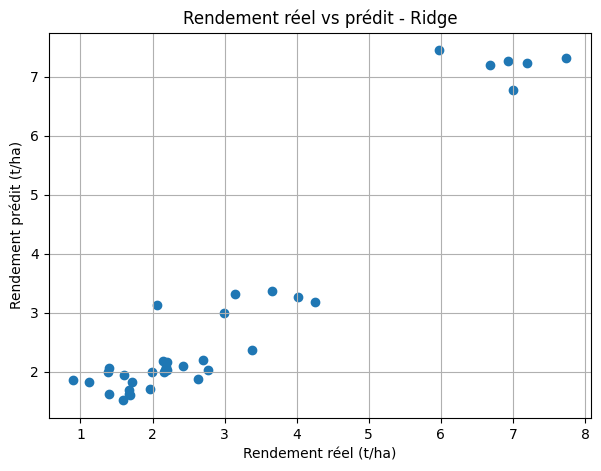

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_best)
plt.xlabel("Rendement réel (t/ha)")
plt.ylabel("Rendement prédit (t/ha)")
plt.title(f"Rendement réel vs prédit - {best_model_name}")
plt.grid(True)
plt.show()

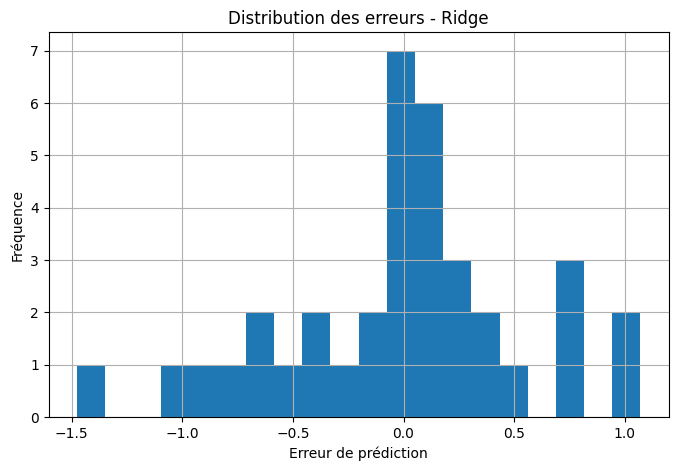

In [30]:
plt.figure(figsize=(8, 5))
plt.hist(comparison_df["error"], bins=20)
plt.xlabel("Erreur de prédiction")
plt.ylabel("Fréquence")
plt.title(f"Distribution des erreurs - {best_model_name}")
plt.grid(True)
plt.show()

In [31]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.DataFrame({
        "feature": X_train.columns,
        "importance": best_model.feature_importances_
    }).sort_values("importance", ascending=False)

    display(importances.head(20))

    plt.figure(figsize=(10, 6))
    plt.barh(importances.head(20)["feature"], importances.head(20)["importance"])
    plt.gca().invert_yaxis()
    plt.xlabel("Importance")
    plt.title(f"Top 20 variables importantes - {best_model_name}")
    plt.show()
else:
    print("Ce modèle ne fournit pas directement feature_importances_.")

Ce modèle ne fournit pas directement feature_importances_.


In [32]:
import joblib

joblib.dump(best_model, "/content/best_yield_prediction_model.pkl")
joblib.dump(X.columns.tolist(), "/content/model_feature_columns.pkl")

comparison_df.to_csv("/content/predictions_vs_real.csv", index=False)
results_df.to_csv("/content/model_evaluation_results.csv", index=False)

print("Modèle sauvegardé : /content/best_yield_prediction_model.pkl")
print("Colonnes sauvegardées : /content/model_feature_columns.pkl")
print("Résultats sauvegardés : /content/model_evaluation_results.csv")
print("Prédictions sauvegardées : /content/predictions_vs_real.csv")

Modèle sauvegardé : /content/best_yield_prediction_model.pkl
Colonnes sauvegardées : /content/model_feature_columns.pkl
Résultats sauvegardés : /content/model_evaluation_results.csv
Prédictions sauvegardées : /content/predictions_vs_real.csv


In [34]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Charger le modèle et les colonnes
model = joblib.load("/content/best_yield_prediction_model.pkl")
feature_columns = joblib.load("/content/model_feature_columns.pkl")

print("Modèle chargé :", type(model))
print("Nombre de colonnes :", len(feature_columns))
print(feature_columns[:10])

Modèle chargé : <class 'sklearn.linear_model._ridge.Ridge'>
Nombre de colonnes : 19
['year', 't2m_mean_C', 't2m_std_C', 'u10_mean_ms', 'u10_std_ms', 'v10_mean_ms', 'v10_std_ms', 'msl_mean_hPa', 'msl_std_hPa', 'tp_mean_mm']


In [35]:
df = pd.read_csv("/content/final_yield_climate_6countries.csv")

df["country"] = df["country"].astype(str).str.strip()
df["crop"] = df["crop"].astype(str).str.strip()
df["year"] = df["year"].astype(int)

display(df.head())

,country,crop,year,time,yield,unit,t2m_mean_C,t2m_std_C,u10_mean_ms,u10_std_ms,v10_mean_ms,v10_std_ms,msl_mean_hPa,msl_std_hPa,tp_mean_mm,tp_std_mm,tp_total_mm,wind_speed_mean_ms,wind_speed_std_ms
0,Algeria,Wheat,1986,1986-01-01,808.4,kg/ha,21.851824,10.091339,-0.508764,3.381768,-0.985028,2.792796,1015.285461,6.278906,0.016399,0.140636,23.942612,4.010180,2.093717
1,Algeria,Wheat,1987,1987-01-01,777.7,kg/ha,23.107790,9.985670,-0.517555,3.323532,-0.598755,2.900478,1014.488281,5.589999,0.015498,0.137721,22.627495,3.957959,2.102279
2,Algeria,Wheat,1988,1988-01-01,600.6,kg/ha,22.502146,10.146104,-0.666909,3.355321,-0.792162,2.825436,1014.448669,6.131284,0.015374,0.135042,22.508230,3.995898,2.084787
3,Algeria,Wheat,1989,1989-01-01,782.1,kg/ha,22.634157,9.743163,-0.789423,3.386235,-0.607691,2.795604,1014.908630,6.290480,0.018338,0.163029,26.773914,3.979679,2.106326
4,Algeria,Wheat,1990,1990-01-01,631.5,kg/ha,22.776155,9.970360,-0.865302,3.285680,-0.819671,2.759428,1015.254211,5.887620,0.015849,0.132025,23.139275,3.930710,2.092910


In [36]:
def convert_yield_to_t_ha(row):
    unit = str(row["unit"]).lower()
    value = row["yield"]

    if "kg/ha" in unit:
        return value / 1000
    elif "hg/ha" in unit:
        return value * 0.0001
    elif "t/ha" in unit or "tonnes/ha" in unit:
        return value
    else:
        return np.nan

df["yield_t_ha"] = df.apply(convert_yield_to_t_ha, axis=1)

df = df.dropna(subset=["yield_t_ha"])

display(df[["country", "crop", "year", "yield", "unit", "yield_t_ha"]].head())

,country,crop,year,yield,unit,yield_t_ha
0,Algeria,Wheat,1986,808.4,kg/ha,0.8084
1,Algeria,Wheat,1987,777.7,kg/ha,0.7777
2,Algeria,Wheat,1988,600.6,kg/ha,0.6006
3,Algeria,Wheat,1989,782.1,kg/ha,0.7821
4,Algeria,Wheat,1990,631.5,kg/ha,0.6315


In [37]:
features = [
    "country",
    "crop",
    "year",
    "t2m_mean_C",
    "t2m_std_C",
    "u10_mean_ms",
    "u10_std_ms",
    "v10_mean_ms",
    "v10_std_ms",
    "msl_mean_hPa",
    "msl_std_hPa",
    "tp_mean_mm",
    "tp_std_mm",
    "tp_total_mm",
    "wind_speed_mean_ms",
    "wind_speed_std_ms"
]

target = "yield_t_ha"

df_model = df[features + [target]].dropna().copy()

X_raw = df_model[features]
y = df_model[target]

# Encoder country et crop comme avant
X = pd.get_dummies(X_raw, columns=["country", "crop"], drop_first=True)

# Très important : garder exactement les mêmes colonnes que pendant l'entraînement
X = X.reindex(columns=feature_columns, fill_value=0)

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())

X shape: (234, 19)
y shape: (234,)


,year,t2m_mean_C,t2m_std_C,u10_mean_ms,u10_std_ms,v10_mean_ms,v10_std_ms,msl_mean_hPa,msl_std_hPa,tp_mean_mm,tp_std_mm,tp_total_mm,wind_speed_mean_ms,wind_speed_std_ms,country_France,country_Mauritania,country_Morocco,country_Portugal,country_Spain
0,1986,21.851824,10.091339,-0.508764,3.381768,-0.985028,2.792796,1015.285461,6.278906,0.016399,0.140636,23.942612,4.010180,2.093717,False,False,False,False,False
1,1987,23.107790,9.985670,-0.517555,3.323532,-0.598755,2.900478,1014.488281,5.589999,0.015498,0.137721,22.627495,3.957959,2.102279,False,False,False,False,False
2,1988,22.502146,10.146104,-0.666909,3.355321,-0.792162,2.825436,1014.448669,6.131284,0.015374,0.135042,22.508230,3.995898,2.084787,False,False,False,False,False
3,1989,22.634157,9.743163,-0.789423,3.386235,-0.607691,2.795604,1014.908630,6.290480,0.018338,0.163029,26.773914,3.979679,2.106326,False,False,False,False,False
4,1990,22.776155,9.970360,-0.865302,3.285680,-0.819671,2.759428,1015.254211,5.887620,0.015849,0.132025,23.139275,3.930710,2.092910,False,False,False,False,False


In [38]:
y_pred = model.predict(X)

mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("Performance sur tout le dataset :")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Performance sur tout le dataset :
MAE : 0.3405811126110019
RMSE: 0.44535214291100694
R²  : 0.9501963008498001


In [39]:
result_global = permutation_importance(
    model,
    X,
    y,
    n_repeats=20,
    random_state=42,
    scoring="neg_mean_squared_error"
)

global_importance = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": result_global.importances_mean,
    "importance_std": result_global.importances_std
}).sort_values("importance_mean", ascending=False)

display(global_importance.head(20))

,feature,importance_mean,importance_std
14,country_France,1.925744e+00,1.295393e-01
1,t2m_mean_C,1.267510e+00,9.969085e-02
17,country_Portugal,6.543955e-01,5.256246e-02
0,year,2.864979e-01,2.749257e-02
15,country_Mauritania,2.351570e-01,1.720633e-02
16,country_Morocco,1.559586e-01,1.684185e-02
18,country_Spain,1.390916e-01,1.528673e-02
11,tp_total_mm,1.020320e-01,1.270752e-02
13,wind_speed_std_ms,7.007420e-02,1.079815e-02
2,t2m_std_C,1.848215e-02,4.504114e-03


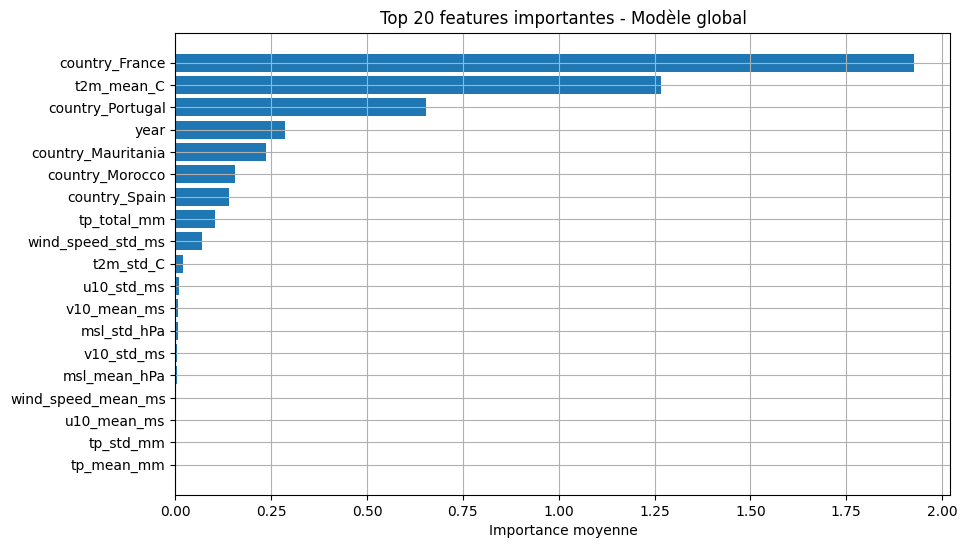

In [40]:
top_global = global_importance.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_global["feature"], top_global["importance_mean"])
plt.gca().invert_yaxis()
plt.xlabel("Importance moyenne")
plt.title("Top 20 features importantes - Modèle global")
plt.grid(True)
plt.show()

In [41]:
country_importance_list = []

countries = df_model["country"].unique()

for country in countries:
    print("\n==============================")
    print("Pays :", country)
    print("==============================")

    mask_country = df_model["country"] == country

    X_country = X[mask_country]
    y_country = y[mask_country]

    print("Nombre de lignes :", X_country.shape[0])

    if X_country.shape[0] < 5:
        print("Pas assez de données pour ce pays.")
        continue

    result_country = permutation_importance(
        model,
        X_country,
        y_country,
        n_repeats=30,
        random_state=42,
        scoring="neg_mean_squared_error"
    )

    importance_country = pd.DataFrame({
        "country": country,
        "feature": X_country.columns,
        "importance_mean": result_country.importances_mean,
        "importance_std": result_country.importances_std
    }).sort_values("importance_mean", ascending=False)

    country_importance_list.append(importance_country)

    display(importance_country.head(15))


Pays : Algeria
Nombre de lignes : 39


,country,feature,importance_mean,importance_std
0,Algeria,year,3.138195e-01,6.110674e-02
1,Algeria,t2m_mean_C,1.901994e-02,8.217528e-03
7,Algeria,msl_mean_hPa,3.196875e-03,8.315356e-04
11,Algeria,tp_total_mm,3.047448e-03,1.208116e-03
13,Algeria,wind_speed_std_ms,1.597324e-03,8.881059e-04
4,Algeria,u10_std_ms,9.891149e-04,9.880585e-04
3,Algeria,u10_mean_ms,6.700431e-04,3.417197e-04
9,Algeria,tp_mean_mm,7.760389e-08,3.740581e-08
17,Algeria,country_Portugal,0.000000e+00,0.000000e+00
15,Algeria,country_Mauritania,0.000000e+00,0.000000e+00



Pays : France
Nombre de lignes : 39


,country,feature,importance_mean,importance_std
0,France,year,1.940226e-01,7.221887e-02
1,France,t2m_mean_C,2.539127e-02,1.734254e-02
13,France,wind_speed_std_ms,2.303414e-03,6.518807e-03
10,France,tp_std_mm,1.041430e-03,5.154279e-04
5,France,v10_mean_ms,7.852286e-04,3.393569e-03
7,France,msl_mean_hPa,3.144893e-04,4.630415e-03
3,France,u10_mean_ms,3.804657e-05,1.189959e-03
17,France,country_Portugal,0.000000e+00,0.000000e+00
15,France,country_Mauritania,0.000000e+00,0.000000e+00
14,France,country_France,0.000000e+00,0.000000e+00



Pays : Mauritania
Nombre de lignes : 39


...

,country,feature,importance_mean,importance_std
0,Morocco,year,2.117504e-01,7.872029e-02
1,Morocco,t2m_mean_C,3.231904e-02,1.556784e-02
11,Morocco,tp_total_mm,1.158340e-02,7.408915e-03
13,Morocco,wind_speed_std_ms,8.854999e-03,4.829541e-03
4,Morocco,u10_std_ms,2.544706e-03,4.246611e-03
5,Morocco,v10_mean_ms,1.864468e-03,3.340243e-03
7,Morocco,msl_mean_hPa,1.669620e-03,2.923019e-03
3,Morocco,u10_mean_ms,1.968279e-04,1.134327e-03
9,Morocco,tp_mean_mm,2.739360e-07,2.329463e-07
17,Morocco,country_Portugal,0.000000e+00,0.000000e+00



Pays : Portugal
Nombre de lignes : 39


,country,feature,importance_mean,importance_std
0,Portugal,year,2.469279e-01,7.058425e-02
1,Portugal,t2m_mean_C,1.775662e-02,1.410054e-02
2,Portugal,t2m_std_C,6.221196e-03,3.179733e-03
5,Portugal,v10_mean_ms,4.711521e-03,3.497351e-03
8,Portugal,msl_std_hPa,3.803003e-03,5.019046e-03
6,Portugal,v10_std_ms,2.446730e-03,2.426392e-03
10,Portugal,tp_std_mm,1.825581e-03,8.150503e-04
12,Portugal,wind_speed_mean_ms,1.112598e-03,9.574517e-04
3,Portugal,u10_mean_ms,3.580803e-04,9.110642e-04
14,Portugal,country_France,0.000000e+00,0.000000e+00



Pays : Spain
Nombre de lignes : 39


,country,feature,importance_mean,importance_std
0,Spain,year,3.326215e-01,7.646737e-02
11,Spain,tp_total_mm,2.082860e-02,9.511978e-03
1,Spain,t2m_mean_C,1.871263e-02,1.215817e-02
2,Spain,t2m_std_C,5.950732e-03,3.378078e-03
8,Spain,msl_std_hPa,2.355323e-03,2.932101e-03
7,Spain,msl_mean_hPa,1.777883e-03,3.613708e-03
6,Spain,v10_std_ms,1.155913e-03,1.575597e-03
4,Spain,u10_std_ms,1.042576e-03,3.819301e-03
12,Spain,wind_speed_mean_ms,4.807528e-04,9.094912e-04
13,Spain,wind_speed_std_ms,2.149930e-04,5.121412e-03


In [42]:
all_country_importance = pd.concat(country_importance_list, ignore_index=True)

output_path = "/content/feature_importance_by_country.csv"
all_country_importance.to_csv(output_path, index=False)

print("Fichier sauvegardé :", output_path)

display(all_country_importance.head(20))

Fichier sauvegardé : /content/feature_importance_by_country.csv


,country,feature,importance_mean,importance_std
0,Algeria,year,3.138195e-01,6.110674e-02
1,Algeria,t2m_mean_C,1.901994e-02,8.217528e-03
2,Algeria,msl_mean_hPa,3.196875e-03,8.315356e-04
3,Algeria,tp_total_mm,3.047448e-03,1.208116e-03
4,Algeria,wind_speed_std_ms,1.597324e-03,8.881059e-04
5,Algeria,u10_std_ms,9.891149e-04,9.880585e-04
6,Algeria,u10_mean_ms,6.700431e-04,3.417197e-04
7,Algeria,tp_mean_mm,7.760389e-08,3.740581e-08
8,Algeria,country_Portugal,0.000000e+00,0.000000e+00
9,Algeria,country_Mauritania,0.000000e+00,0.000000e+00


In [43]:
climate_features = [
    "t2m_mean_C",
    "t2m_std_C",
    "u10_mean_ms",
    "u10_std_ms",
    "v10_mean_ms",
    "v10_std_ms",
    "msl_mean_hPa",
    "msl_std_hPa",
    "tp_mean_mm",
    "tp_std_mm",
    "tp_total_mm",
    "wind_speed_mean_ms",
    "wind_speed_std_ms"
]

climate_importance_by_country = all_country_importance[
    all_country_importance["feature"].isin(climate_features)
].copy()

display(climate_importance_by_country.head(30))

,country,feature,importance_mean,importance_std
1,Algeria,t2m_mean_C,1.901994e-02,8.217528e-03
2,Algeria,msl_mean_hPa,3.196875e-03,8.315356e-04
3,Algeria,tp_total_mm,3.047448e-03,1.208116e-03
4,Algeria,wind_speed_std_ms,1.597324e-03,8.881059e-04
5,Algeria,u10_std_ms,9.891149e-04,9.880585e-04
6,Algeria,u10_mean_ms,6.700431e-04,3.417197e-04
7,Algeria,tp_mean_mm,7.760389e-08,3.740581e-08
13,Algeria,wind_speed_mean_ms,-1.214515e-04,1.285304e-04
14,Algeria,tp_std_mm,-2.461335e-04,1.473302e-04
15,Algeria,v10_mean_ms,-6.176347e-04,7.512182e-04


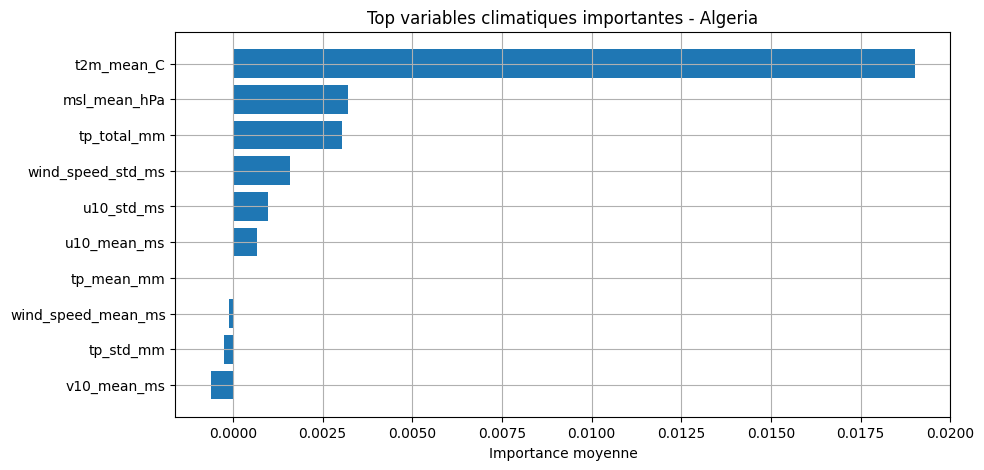

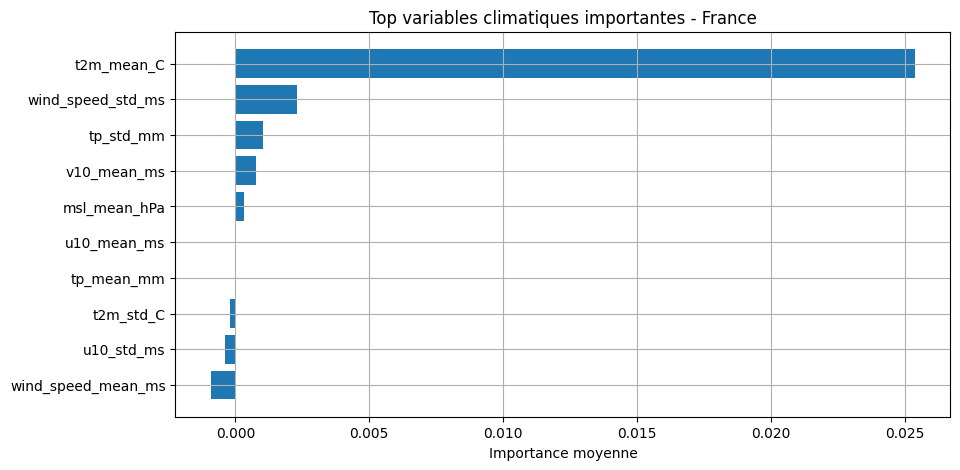

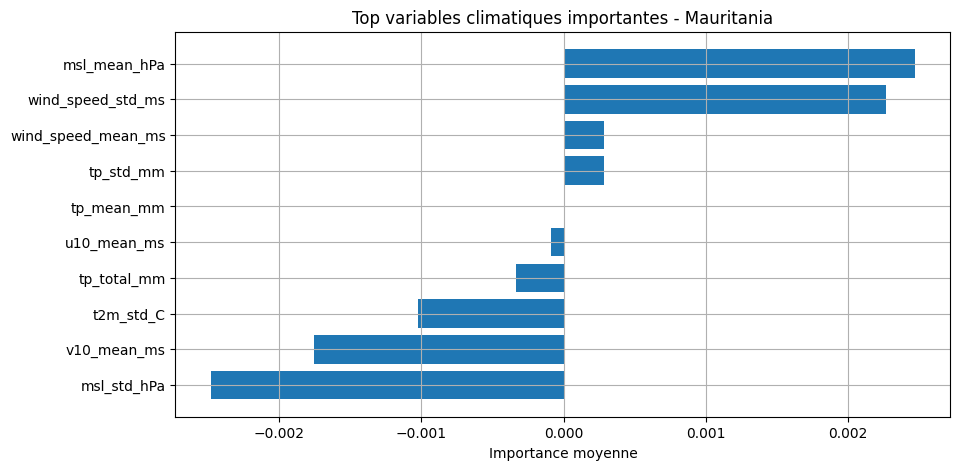

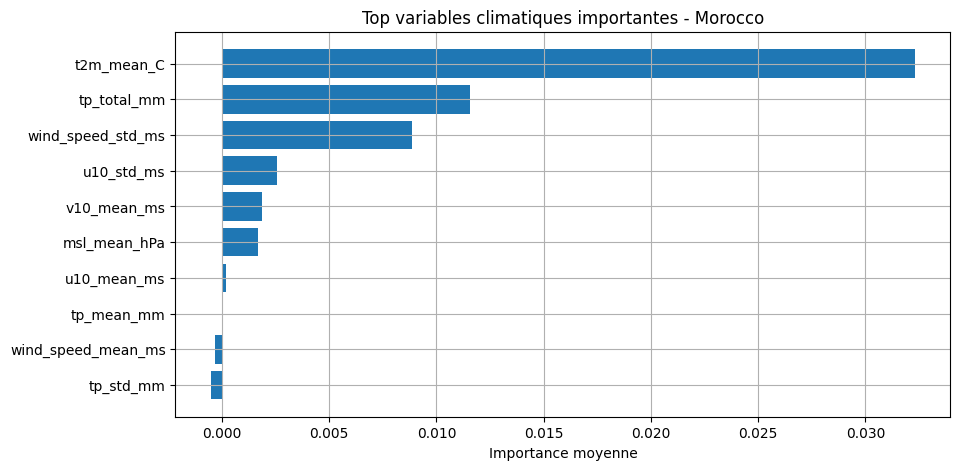

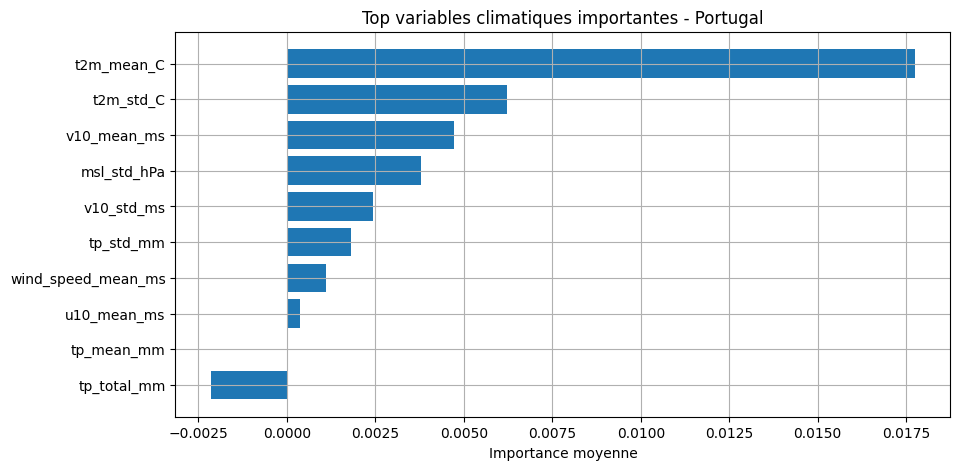

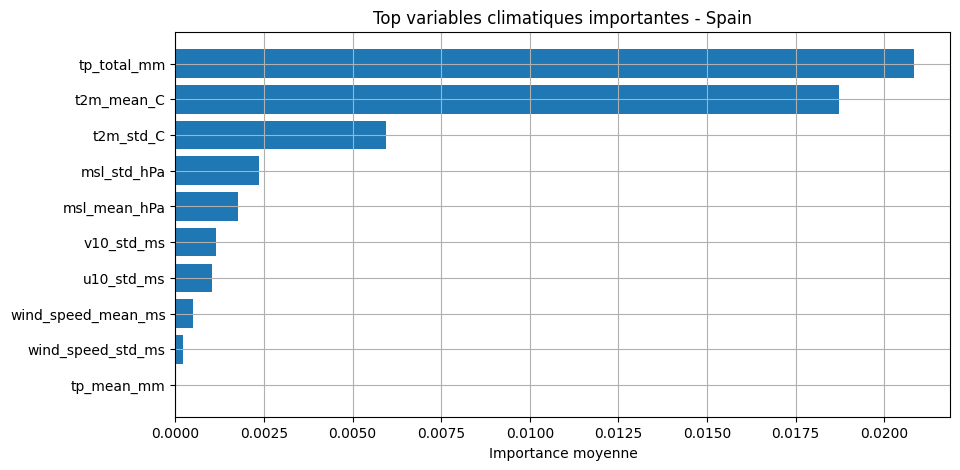

In [44]:
for country in climate_importance_by_country["country"].unique():
    temp = climate_importance_by_country[
        climate_importance_by_country["country"] == country
    ].sort_values("importance_mean", ascending=False).head(10)

    plt.figure(figsize=(10, 5))
    plt.barh(temp["feature"], temp["importance_mean"])
    plt.gca().invert_yaxis()
    plt.xlabel("Importance moyenne")
    plt.title(f"Top variables climatiques importantes - {country}")
    plt.grid(True)
    plt.show()

In [45]:
top_climate_by_country = (
    climate_importance_by_country
    .sort_values(["country", "importance_mean"], ascending=[True, False])
    .groupby("country")
    .head(5)
)

display(top_climate_by_country)

,country,feature,importance_mean,importance_std
1,Algeria,t2m_mean_C,1.901994e-02,8.217528e-03
2,Algeria,msl_mean_hPa,3.196875e-03,8.315356e-04
3,Algeria,tp_total_mm,3.047448e-03,1.208116e-03
4,Algeria,wind_speed_std_ms,1.597324e-03,8.881059e-04
5,Algeria,u10_std_ms,9.891149e-04,9.880585e-04
20,France,t2m_mean_C,2.539127e-02,1.734254e-02
21,France,wind_speed_std_ms,2.303414e-03,6.518807e-03
22,France,tp_std_mm,1.041430e-03,5.154279e-04
23,France,v10_mean_ms,7.852286e-04,3.393569e-03
24,France,msl_mean_hPa,3.144893e-04,4.630415e-03


In [46]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# =========================
# 1. Charger dataset
# =========================

df = pd.read_csv("/content/final_yield_climate_6countries.csv")

df["country"] = df["country"].astype(str).str.strip()
df["crop"] = df["crop"].astype(str).str.strip()
df["year"] = df["year"].astype(int)

# =========================
# 2. Convertir yield vers t/ha
# =========================

def convert_yield_to_t_ha(row):
    unit = str(row["unit"]).lower()
    value = row["yield"]

    if "kg/ha" in unit:
        return value / 1000
    elif "hg/ha" in unit:
        return value * 0.0001
    elif "t/ha" in unit or "tonnes/ha" in unit:
        return value
    else:
        return np.nan

df["yield_t_ha"] = df.apply(convert_yield_to_t_ha, axis=1)

# =========================
# 3. Colonnes utiles
# =========================

features = [
    "country",
    "crop",
    "year",
    "t2m_mean_C",
    "t2m_std_C",
    "u10_mean_ms",
    "u10_std_ms",
    "v10_mean_ms",
    "v10_std_ms",
    "msl_mean_hPa",
    "msl_std_hPa",
    "tp_mean_mm",
    "tp_std_mm",
    "tp_total_mm",
    "wind_speed_mean_ms",
    "wind_speed_std_ms"
]

target = "yield_t_ha"

df_model = df[features + [target]].dropna().copy()

# Encoder country et crop
X = pd.get_dummies(df_model[features], columns=["country", "crop"], drop_first=True)
y = df_model[target].values

# =========================
# 4. Split temporel
# =========================

train_mask = X["year"] <= 2018
test_mask = X["year"] > 2018

X_train = X[train_mask].values
X_test = X[test_mask].values

y_train = y[train_mask]
y_test = y[test_mask]

# =========================
# 5. Normalisation
# =========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape)
print("Test:", X_test_scaled.shape)

Train: (198, 19)
Test: (36, 19)


In [47]:
def build_mlp_simple(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model


mlp_simple = build_mlp_simple(X_train_scaled.shape[1])

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=30,
    restore_best_weights=True
)

history_mlp_simple = mlp_simple.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

y_pred_mlp_simple = mlp_simple.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, y_pred_mlp_simple)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlp_simple))
r2 = r2_score(y_test, y_pred_mlp_simple)

print("MLP Simple")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

Epoch 1/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 12.3803 - mae: 2.6116 - val_loss: 5.7186 - val_mae: 2.3078
Epoch 2/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.7489 - mae: 1.9140 - val_loss: 2.9633 - val_mae: 1.6129
Epoch 3/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.2859 - mae: 1.5273 - val_loss: 1.2360 - val_mae: 0.9663
Epoch 4/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.2116 - mae: 1.2460 - val_loss: 0.3757 - val_mae: 0.5012
Epoch 5/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.5479 - mae: 1.0490 - val_loss: 0.4652 - val_mae: 0.5511
Epoch 6/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2544 - mae: 0.8202 - val_loss: 1.2969 - val_mae: 1.0168
Epoch 7/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6081 - mae: 0.6145 - val_loss: 2.1934 - val_mae: 1.3751
Epoch 8/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4020 - mae: 0.5086 - val_loss: 2.6704 - val_mae: 1.5044
Epoch 9/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2

In [48]:
def build_deep_mlp(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(32, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.1),

        layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0007),
        loss="mse",
        metrics=["mae"]
    )

    return model


deep_mlp = build_deep_mlp(X_train_scaled.shape[1])

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=40,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=15,
    min_lr=1e-5
)

history_deep_mlp = deep_mlp.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=16,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

y_pred_deep_mlp = deep_mlp.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, y_pred_deep_mlp)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_deep_mlp))
r2 = r2_score(y_test, y_pred_deep_mlp)

print("Deep MLP")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 10.6499 - mae: 2.6719 - val_loss: 7.2755 - val_mae: 2.6433 - learning_rate: 7.0000e-04
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.6577 - mae: 2.5027 - val_loss: 6.1655 - val_mae: 2.4314 - learning_rate: 7.0000e-04
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.3773 - mae: 2.4367 - val_loss: 5.2892 - val_mae: 2.2484 - learning_rate: 7.0000e-04
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.0193 - mae: 2.4121 - val_loss: 4.4905 - val_mae: 2.0648 - learning_rate: 7.0000e-04
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.9855 - mae: 2.4076 - val_loss: 3.9843 - val_mae: 1.9393 - learning_rate: 7.0000e-04
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.8473 - mae: 2.3520 - val_loss: 3.5661 - val_mae: 1.8276 - learning_rate: 7.0000e-04
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.3845 - mae: 2.2959 - val_loss: 3.2778 - val_mae: 1.7451 - learning_

In [49]:
# Reshape pour CNN : (samples, features, channels)
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

def build_cnn_1d(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv1D(filters=32, kernel_size=3, activation="relu"),
        layers.BatchNormalization(),

        layers.Conv1D(filters=64, kernel_size=3, activation="relu"),
        layers.BatchNormalization(),

        layers.GlobalAveragePooling1D(),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),

        layers.Dense(32, activation="relu"),

        layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model


cnn_1d = build_cnn_1d((X_train_cnn.shape[1], 1))

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=40,
    restore_best_weights=True
)

history_cnn = cnn_1d.fit(
    X_train_cnn,
    y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

y_pred_cnn = cnn_1d.predict(X_test_cnn).flatten()

mae = mean_absolute_error(y_test, y_pred_cnn)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_cnn))
r2 = r2_score(y_test, y_pred_cnn)

print("1D-CNN")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 5.9169 - mae: 1.6871 - val_loss: 5.7856 - val_mae: 2.3289
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.3472 - mae: 1.0927 - val_loss: 4.4500 - val_mae: 2.0288
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.2949 - mae: 0.8436 - val_loss: 4.0041 - val_mae: 1.9174
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9999 - mae: 0.7531 - val_loss: 3.6846 - val_mae: 1.8323
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8826 - mae: 0.6958 - val_loss: 3.0243 - val_mae: 1.6436
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7125 - mae: 0.6560 - val_loss: 2.4363 - val_mae: 1.4550
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5972 - mae: 0.5909 - val_loss: 1.9605 - val_mae: 1.2819
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8273 - mae: 0.6594 - val_loss: 1.5766 - val_mae: 1.1298
Epoch 9/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1D-CNN
MAE : 1.1455929360230763
RMSE: 1.7018428037632884
R2  : 0.2062786901935505


In [50]:
dl_results = []

predictions = {
    "MLP Simple": y_pred_mlp_simple,
    "Deep MLP": y_pred_deep_mlp,
    "1D-CNN": y_pred_cnn
}

for name, preds in predictions.items():
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    dl_results.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

dl_results_df = pd.DataFrame(dl_results).sort_values("RMSE")

display(dl_results_df)

,model,MAE,RMSE,R2
0,MLP Simple,1.013444,1.520242,0.366634
1,Deep MLP,1.347491,1.535905,0.353516
2,1D-CNN,1.145593,1.701843,0.206279


Meilleur modèle DL : MLP Simple


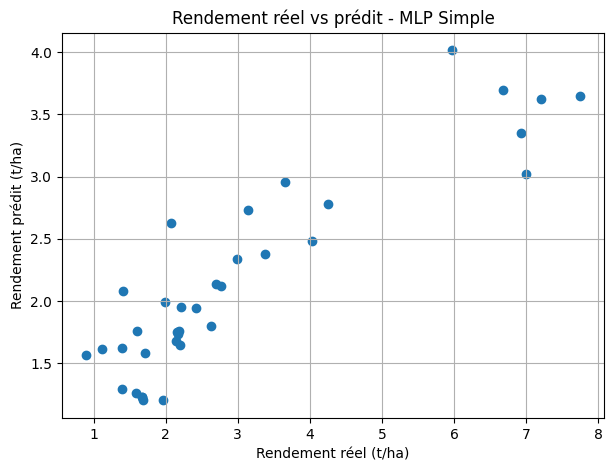

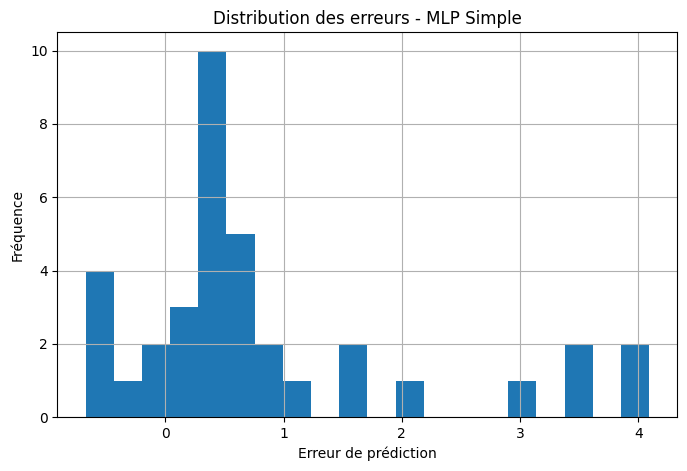

In [51]:
import matplotlib.pyplot as plt

best_dl_name = dl_results_df.iloc[0]["model"]
best_dl_pred = predictions[best_dl_name]

print("Meilleur modèle DL :", best_dl_name)

plt.figure(figsize=(7, 5))
plt.scatter(y_test, best_dl_pred)
plt.xlabel("Rendement réel (t/ha)")
plt.ylabel("Rendement prédit (t/ha)")
plt.title(f"Rendement réel vs prédit - {best_dl_name}")
plt.grid(True)
plt.show()

errors = y_test - best_dl_pred

plt.figure(figsize=(8, 5))
plt.hist(errors, bins=20)
plt.xlabel("Erreur de prédiction")
plt.ylabel("Fréquence")
plt.title(f"Distribution des erreurs - {best_dl_name}")
plt.grid(True)
plt.show()

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

country_results = []

for country in comparison_df["country"].unique():
    temp = comparison_df[comparison_df["country"] == country]

    mae = mean_absolute_error(temp["real_yield_t_ha"], temp["predicted_yield_t_ha"])
    rmse = np.sqrt(mean_squared_error(temp["real_yield_t_ha"], temp["predicted_yield_t_ha"]))
    r2 = r2_score(temp["real_yield_t_ha"], temp["predicted_yield_t_ha"])

    country_results.append({
        "country": country,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

country_results_df = pd.DataFrame(country_results).sort_values("RMSE")
display(country_results_df)

,country,MAE,RMSE,R2
2,Mauritania,0.112543,0.127701,-38.454676
0,Algeria,0.117504,0.150207,0.210911
4,Portugal,0.541297,0.628717,-0.018926
3,Morocco,0.580223,0.643330,-0.347921
1,France,0.500615,0.681769,-0.624381
5,Spain,0.558778,0.702926,0.065282


In [53]:
baseline_df = comparison_df.copy()

# Moyenne historique par pays/culture calculée sur train
train_reference = df_model[df_model["year"] <= 2018]

mean_yield = train_reference.groupby(["country", "crop"])["yield_t_ha"].mean().reset_index()
mean_yield = mean_yield.rename(columns={"yield_t_ha": "baseline_prediction"})

baseline_df = baseline_df.merge(mean_yield, on=["country", "crop"], how="left")

mae_baseline = mean_absolute_error(
    baseline_df["real_yield_t_ha"],
    baseline_df["baseline_prediction"]
)

rmse_baseline = np.sqrt(mean_squared_error(
    baseline_df["real_yield_t_ha"],
    baseline_df["baseline_prediction"]
))

r2_baseline = r2_score(
    baseline_df["real_yield_t_ha"],
    baseline_df["baseline_prediction"]
)

print("Baseline MAE:", mae_baseline)
print("Baseline RMSE:", rmse_baseline)
print("Baseline R2:", r2_baseline)

Baseline MAE: 0.604134595959596
Baseline RMSE: 0.7238354743756668
Baseline R2: 0.856415062855927


Le modèle Ridge est le plus performant parmi les modèles testés. Il obtient le meilleur R², égal à 0,917, ainsi que les erreurs les plus faibles avec un MAE de 0,40 t/ha et un RMSE de 0,55 t/ha. Ce résultat montre qu’un modèle linéaire régularisé est bien adapté à ce dataset tabulaire de rendement agricole et de variables climatiques.

In [54]:
import pandas as pd
import joblib

# =========================
# 1. Charger le modèle et les colonnes
# =========================

model = joblib.load("/content/best_yield_prediction_model.pkl")
feature_columns = joblib.load("/content/model_feature_columns.pkl")

print("Modèle chargé avec succès.")
print("Nombre de features utilisées :", len(feature_columns))

Modèle chargé avec succès.
Nombre de features utilisées : 19


In [55]:
# Dataset climatique
climate_path = "/content/era5_annual_climate_features.csv"
df_climate = pd.read_csv(climate_path)

print(df_climate.shape)
display(df_climate.head())

# Garder seulement l'année 2025
climate_2025 = df_climate[df_climate["year"] == 2025].copy()

display(climate_2025)

(41, 14)


,year,t2m_mean_C,t2m_std_C,u10_mean_ms,u10_std_ms,v10_mean_ms,v10_std_ms,msl_mean_hPa,msl_std_hPa,tp_mean_mm,tp_std_mm,tp_total_mm,wind_speed_mean_ms,wind_speed_std_ms
0,1986,18.998079,9.057467,-0.063470,3.748894,-1.624632,3.708575,1016.873535,6.782884,0.037562,0.208041,54.840034,4.743982,2.818838
1,1987,20.036146,9.148908,-0.210594,3.711394,-1.098676,3.788689,1015.671631,6.280123,0.043016,0.241709,62.803104,4.637420,2.806126
2,1988,19.563393,9.027853,-0.265983,3.828498,-1.328974,3.747299,1015.973022,6.486715,0.037562,0.212499,54.990887,4.738337,2.843358
3,1989,19.924839,8.742700,-0.449306,3.818166,-1.132885,3.759093,1016.130127,7.067433,0.041644,0.238209,60.799606,4.679710,2.880073
4,1990,19.955599,9.001212,-0.445892,3.738601,-1.411732,3.652387,1016.890198,6.455863,0.035241,0.201712,51.452232,4.643445,2.819087


,year,t2m_mean_C,t2m_std_C,u10_mean_ms,u10_std_ms,v10_mean_ms,v10_std_ms,msl_mean_hPa,msl_std_hPa,tp_mean_mm,tp_std_mm,tp_total_mm,wind_speed_mean_ms,wind_speed_std_ms
39,2025,20.891596,9.161106,-0.177015,3.714239,-1.283699,3.882889,1015.860779,5.715983,0.043164,0.242836,63.019333,4.750652,2.825405


In [56]:
countries = [
    "France",
    "Portugal",
    "Spain",
    "Mauritania",
    "Algeria",
    "Morocco"
]

crop = "Wheat"

prediction_rows = []

for country in countries:
    row = climate_2025.iloc[0].to_dict()
    row["country"] = country
    row["crop"] = crop
    prediction_rows.append(row)

df_2025 = pd.DataFrame(prediction_rows)

display(df_2025)

,year,t2m_mean_C,t2m_std_C,u10_mean_ms,u10_std_ms,v10_mean_ms,v10_std_ms,msl_mean_hPa,msl_std_hPa,tp_mean_mm,tp_std_mm,tp_total_mm,wind_speed_mean_ms,wind_speed_std_ms,country,crop
0,2025.0,20.891596,9.161106,-0.177015,3.714239,-1.283699,3.882889,1015.860779,5.715983,0.043164,0.242836,63.019333,4.750652,2.825405,France,Wheat
1,2025.0,20.891596,9.161106,-0.177015,3.714239,-1.283699,3.882889,1015.860779,5.715983,0.043164,0.242836,63.019333,4.750652,2.825405,Portugal,Wheat
2,2025.0,20.891596,9.161106,-0.177015,3.714239,-1.283699,3.882889,1015.860779,5.715983,0.043164,0.242836,63.019333,4.750652,2.825405,Spain,Wheat
3,2025.0,20.891596,9.161106,-0.177015,3.714239,-1.283699,3.882889,1015.860779,5.715983,0.043164,0.242836,63.019333,4.750652,2.825405,Mauritania,Wheat
4,2025.0,20.891596,9.161106,-0.177015,3.714239,-1.283699,3.882889,1015.860779,5.715983,0.043164,0.242836,63.019333,4.750652,2.825405,Algeria,Wheat
5,2025.0,20.891596,9.161106,-0.177015,3.714239,-1.283699,3.882889,1015.860779,5.715983,0.043164,0.242836,63.019333,4.750652,2.825405,Morocco,Wheat


In [57]:
# Colonnes utilisées avant l'encodage
features = [
    "country",
    "crop",
    "year",
    "t2m_mean_C",
    "t2m_std_C",
    "u10_mean_ms",
    "u10_std_ms",
    "v10_mean_ms",
    "v10_std_ms",
    "msl_mean_hPa",
    "msl_std_hPa",
    "tp_mean_mm",
    "tp_std_mm",
    "tp_total_mm",
    "wind_speed_mean_ms",
    "wind_speed_std_ms"
]

X_new = df_2025[features].copy()

# Encoder country et crop comme pendant l'entraînement
X_new_encoded = pd.get_dummies(X_new, columns=["country", "crop"], drop_first=True)

# Très important : remettre exactement les mêmes colonnes que le modèle attend
X_new_encoded = X_new_encoded.reindex(columns=feature_columns, fill_value=0)

print(X_new_encoded.shape)
display(X_new_encoded.head())

(6, 19)


,year,t2m_mean_C,t2m_std_C,u10_mean_ms,u10_std_ms,v10_mean_ms,v10_std_ms,msl_mean_hPa,msl_std_hPa,tp_mean_mm,tp_std_mm,tp_total_mm,wind_speed_mean_ms,wind_speed_std_ms,country_France,country_Mauritania,country_Morocco,country_Portugal,country_Spain
0,2025.0,20.891596,9.161106,-0.177015,3.714239,-1.283699,3.882889,1015.860779,5.715983,0.043164,0.242836,63.019333,4.750652,2.825405,True,False,False,False,False
1,2025.0,20.891596,9.161106,-0.177015,3.714239,-1.283699,3.882889,1015.860779,5.715983,0.043164,0.242836,63.019333,4.750652,2.825405,False,False,False,True,False
2,2025.0,20.891596,9.161106,-0.177015,3.714239,-1.283699,3.882889,1015.860779,5.715983,0.043164,0.242836,63.019333,4.750652,2.825405,False,False,False,False,True
3,2025.0,20.891596,9.161106,-0.177015,3.714239,-1.283699,3.882889,1015.860779,5.715983,0.043164,0.242836,63.019333,4.750652,2.825405,False,True,False,False,False
4,2025.0,20.891596,9.161106,-0.177015,3.714239,-1.283699,3.882889,1015.860779,5.715983,0.043164,0.242836,63.019333,4.750652,2.825405,False,False,False,False,False


In [58]:
# Prédiction
predictions = model.predict(X_new_encoded)

df_predictions_2025 = df_2025[["country", "crop", "year"]].copy()
df_predictions_2025["predicted_yield_t_ha"] = predictions

display(df_predictions_2025)

,country,crop,year,predicted_yield_t_ha
0,France,Wheat,2025.0,5.447540
1,Portugal,Wheat,2025.0,1.267605
2,Spain,Wheat,2025.0,2.104273
3,Mauritania,Wheat,2025.0,3.716704
4,Algeria,Wheat,2025.0,2.813010
5,Morocco,Wheat,2025.0,2.110659


In [59]:
output_path = "/content/predicted_wheat_yield_2025.csv"

df_predictions_2025.to_csv(output_path, index=False)

print("Prédictions sauvegardées ici :", output_path)

Prédictions sauvegardées ici : /content/predicted_wheat_yield_2025.csv


In [61]:
import pandas as pd

df = pd.read_csv("/content/faostat_yield_6countries_from_bulk.csv")

df_2025 = df[
    (df["year"] == 2025) &
    (df["crop"].str.lower().str.contains("wheat", na=False))
]

display(df_2025)

,country,crop,year,yield,unit
